# Badanie Efektywności Reprezentacji Ortogonalnej Sygnałów 1D

Autorzy:
- Grzegorz Cyba, 274859
- Jan Galewicz 272587

Wybrany temat:
*Rozwinięcia ortogonalne w przetwarzaniu i kompresji sygnałów jednowymiarowych*

---

## **1. Wstęp**



Głównym celem projektu było zbadanie właściwości i ograniczeń analizy fourierowskiej, a także ocena jej praktycznej przydatności w procesie stratnej kompresji danych.Transformata Fouriera to potężne narzędzie matematyczne, które pozwala rozłożyć dowolny, nawet bardzo skomplikowany sygnał na sumę sinusów i cosinusów o określonych częstotliwościach i amplitudach. Umożliwia to przetłumaczenie sygnału z domeny czasu lub przestrzeni do domeny częstotliwości, co pozwala na precyzyjną analizę, filtrowanie oraz kompresję danych.

W sprawozdaniu omówiono matematyczne podstawy działania dyskretnej transformaty Fouriera ($DFT$) jak i odwrotnej transformaty Fouriera ($IDFT$). Zaprezentowano autorską implementację klasy DiscreteFourier odpowiedzialnej za wyznaczanie widma, rekonstrukcję sygnału oraz progowanie amplitudowe. Zestawiono ją z biblioteczną implementacją tego algorytmu pakietu **Numpy**. Główną część projektu stanowi badanie zachowania transformaty pod kątem zachowania energii oraz dokładności odtworzenia sygnałów (pomiar MSE oraz MaxError).

Transformata Fouriera jest szeroko stosowana w różnych dziedzinach. Główne dziedziny to telekomunikacja, diagnostyka medyczna (przetwarzanie obrazów) oraz analiza oraz przetwarzanie sygnałów. Jako przykład praktyczny w projekcie przeprwadzono kompresję audio. Sprawdzono wpływ różnego poziomu kompresji na wielkość zapisanego pliku oraz jakość dźwięku. Do wykonania dokładnej analizy, zaimplementowano własny koder audio który pozwolił dokładnie zbadać działanie transformaty Fouriera.    

---

## **2. Generator danych**

W celu przeprowadzenia kompleksowej weryfikacji efektywności algorytmu kompresji widmowej opartego na transformacie Fouriera, niezbędne było przygotowanie zróżnicowanego materiału badawczego. Zaimplementowane środowisko pozwala na generowanie trzech klas sygnałów o odmiennych właściwościach w domenie czasu i częstotliwości. Pozwala to na rygorystyczne przetestowanie mechanizmu progowania współczynników pod kątem dokładności rekonstrukcji, zachowania energii oraz zmian entropii sygnału.

### **2.1. Budowa zbioru danych i symulacja zaszumienia pomiarowego**

Masowa synteza oraz agregacja struktur sygnałowych realizowana jest przez klasę zarządczą *DatasetCreator*. Narzędzie to automatyzuje proces budowy zbalansowanego datasetu testowego w dyskretnej dziedzinie czasu dla następujących parametrów:
- $t_0 = 0\text{ s}$ — czas początkowy przebiegu,
- $t_{end} = 500\text{ s}$ — czas końcowy przebiegu,
- $dt = 0.1\text{ s}$ — krok czasowy (co daje wektor o długości 5000 próbek),
- $u(t) \in [1, 10]$ — zakres dopuszczalnych wartości (amplitud).

**Powtarzalność i determinizm widma:**

W celu zapewnienia pełnej replikowalności eksperymentów, klasa wykorzystuje obiektowy generator liczb pseudolosowych `np.random.default_rng(seed)`. Przekazywanie tej samej instancji stanu losowego (`rng`) do klas sygnałowych gwarantuje, że przy identycznym ziarnie (seed) wygenerowane trajektorie czasowe oraz ich struktura spektralna (układ harmonicznych w widmie) będą identyczne przy każdym uruchomieniu.

**Separacja i kontekst badawczy zaszumienia**

Architektura generatora umożliwia ścisły podział na fazę syntezy danych czystych oraz eksperymentów szumowych poprzez tworzenie głębokich kopii bazy danych i nakładanie na nie zakłóceń Gaussowskich $(y_{noisy} = y_{clean} + N(0, \sigma))$ z zastosowaniem saturacji `np.clip` do barier fizycznych $[u_{min}, u_{max}]$. 

**Warto jednak podkreślić, że w dalszej części projektu oraz w zasadniczych testach algorytmów kompresji Fouriera skupiono się wyłącznie na danych niezaszumionych (czystych).** Pozwoliło to na rygorystyczną ocenę właściwości aproksymacyjnych samego transformatora widmowego, bez zniekształcania ocen jakości przez losowe artefakty szerokopasmowe.

Wygenerowane pakiety czystych danych (wektory $t$ oraz $y$) są ostatecznie kapsułkowane w ustrukturyzowanych obiektach klasy `SignalData` i mapowane w zbiorczym słowniku pod kluczami odpowiadającymi trzem odrębnym klasom sygnałów o zróżnicowanej naturze spektralnej: 

* **sygnałom skokowym (APRBS)**, 
* **wieloczęstotliwościowym (Multisine)**, 
* **stochastycznym (Filtered Noise)**. 

Szczegółowa charakterystyka matematyczna oraz spektralna każdej z tych trzech klas została zaprezentowana w kolejnym podrozdziale (pkt 2.2).

### **2.2 Klasy sygnałów**

Każda z zaimplementowanych klas sygnału reprezentuje inny typ struktury spektralnej, co pozwala na ocenę uniwersalności projektowanego kodeka.


#### ***2.2.1. Sygnał APRBS (Amplitude Pseudo-Random Binary Sequence)***


Sygnał ten charakteryzuje się gwałtownymi, dyskretnymi zmianami amplitudy (skokami napięcia) utrzymywanymi przez losowy czas. Dla każdego pojedynczego przebiegu parametry czasowe są losowane stochastycznie z następujących zakresów:
- $h_{min} \in [50; 150]$ — zakres, z którego losowany jest minimalny czas trwania pojedynczego kroku,
- $h_{add} \in [100; 300]$ — przedział definiujący dodatkowy czas, który po zsumowaniu z $h_{min}$ określa maksymalny czas trwania kroku ($h_{max}$).

**Znaczenie w analizie kompresji:** Z punktu widzenia analizy Fouriera, ostre zbocza i nieskończony gradient zmian w dziedzinie czasu generują ciągłe, bardzo bogate spektrum częstotliwościowe o wolno wygasających harmonicznych. Jest to najtrudniejszy test dla algorytmu kompresji widmowej. Wycięcie wysokich częstotliwości (współczynników FFT) prowadzi do utraty ostrości krawędzi i generuje charakterystyczne oscylacje wokół punktów skoku po wykonaniu odwrotnej transformaty (tzw. efekt Gibbsa). Pozwala to zbadać, jak mocno ucinanie pasma zniekształca skokowe sygnały szybkozmienne.

**Przykładowe przebiegi sygnałów typu APRBS**

Tworzony jest zbiór danych składający się z dziesięciu sygnałów typu APRBS. Przy użyciu dedykowanego modułu wizualizacji, generowany jest interaktywny wykres przedstawiający przebiegi trzech wybranych sygnałów z utworzonej bazy.

Generowanie APRBS        :   0%|          | 0/10 [00:00<?, ?it/s]

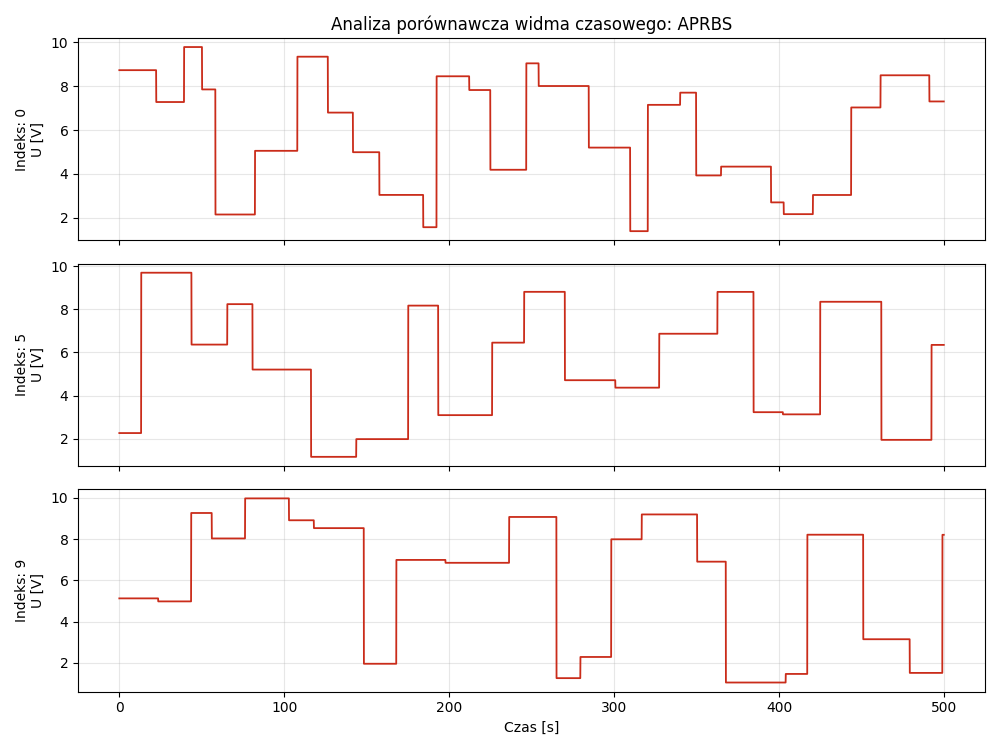

In [18]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.2, seed=42)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=0, n_noise=0)

Plotter.plot_indices(dataset['aprbs'], "aprbs", indices=[0, 5, 9])

# dataset_noisy = creator.create_noisy_dataset_copy()
# Plotter.plot_indices(dataset['aprbs'], "aprbs", indices=[0, 5, 9], signals_noisy=dataset_noisy['aprbs'], noise_level=creator.noise_level)

#### ***2.2.2. Sygnał Multisine (Wieloczęstotliwościowy)***

Sygnał ten stanowi deterministyczną sumę składowych harmonicznych (sinusoid) o losowych fazach i częstotliwościach. Dla każdego przebiegu parametry konfiguracyjne losowane są z przedziałów:
- $n_f \in [5; 15]$ — zakres, z którego losowana jest liczba składowych sinusoidalnych,
- $f_{max} \in [0.005; 0.02]\text{ Hz}$ — zakres, z którego losowana jest maksymalna dopuszczalna częstotliwość pojedynczej sinusoidy.

**Znaczenie w analizie kompresji:** W dziedzinie częstotliwości sygnał ten charakteryzuje się ściśle dyskretnym spektrum prążkowym. Cała energia sygnału skupiona jest w dokładnie $n_f$ punktach widma, podczas gdy pozostała część pasma przyjmuje wartości zerowe. Dla kodeka fourierowskiego jest to sygnał idealny. Algorytm progowania powinien bezbłędnie wyizolować i zachować wyłącznie dominujące prążki częstotliwościowe, co pozwala na uzyskanie minimalnego błędu rekonstrukcji (MSE) i stabilnej entropii widmowej nawet przy bardzo niskim procencie zachowanych danych.

**Przykładowe przebiegi sygnałów typu Multisine**

Tworzony jest zbiór danych składający się z dziesięciu sygnałów typu Multisine. Przy użyciu dedykowanego modułu wizualizacji, generowany jest interaktywny wykres przedstawiający przebiegi trzech wybranych sygnałów z utworzonej baz

Generowanie MULTISINE    :   0%|          | 0/10 [00:00<?, ?it/s]

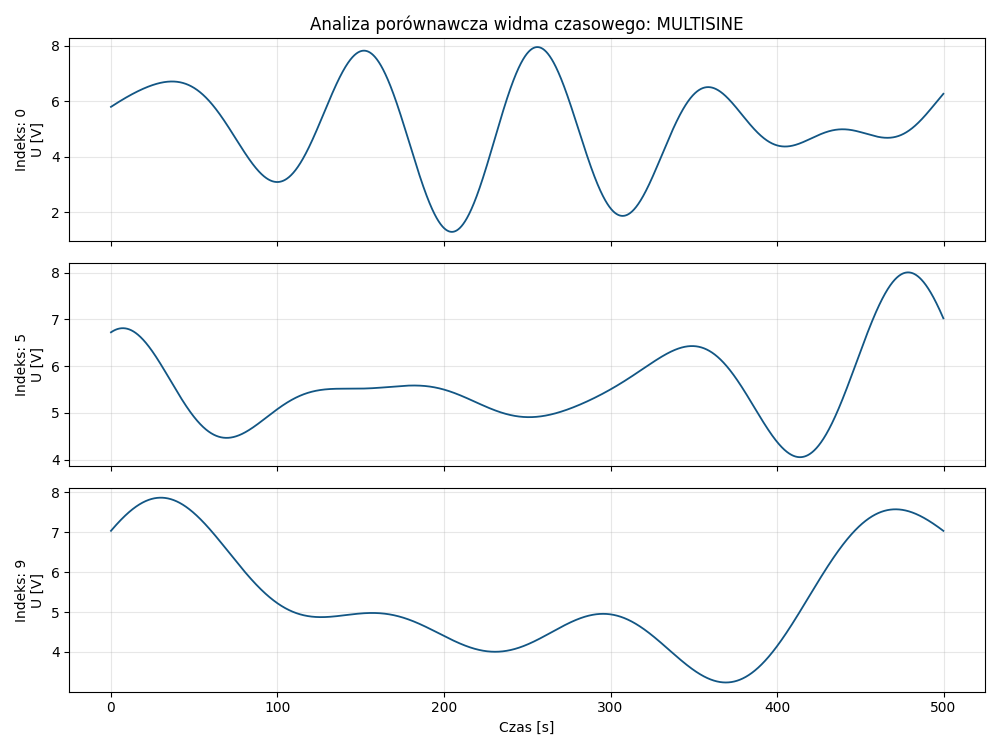

In [19]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.2, seed=42)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=10, n_noise=0)

Plotter.plot_indices(dataset['multisine'], "multisine", indices=[0, 5, 9])

# dataset_noisy = creator.create_noisy_dataset_copy()
# Plotter.plot_indices(dataset['multisine'], "multisine", indices=[0, 5, 9], signals_noisy=dataset_noisy['multisine'], noise_level=creator.noise_level)

#### ***2.2.3. Przefiltrowany szum dolnoprzepustowy (Filtered Noise)***

Sygnał reprezentujący przebieg chaotyczny o kontrolowanym paśmie. Powstaje poprzez generację stochastycznego szumu białego o rozkładzie normalnym, który następnie poddawany jest cyfrowej filtracji dolnoprzepustowej pierwszego rzędu. Częstotliwość odcięcia filtra jest parametrem losowym:
- $cutoff \in [0.001; 0.01]\text{ Hz}$ — zakres losowania częstotliwości odcięcia.

**Znaczenie w analizie kompresji:** W dziedzinie częstotliwości sygnał ten posiada gęste, ciągłe pasmo szumowe ograniczone od góry filtrem wygładzającym. Brak pojedynczych, dominujących częstotliwości sprawia, że energia jest rozproszona. Pozwala to na zbadanie, jak algorytm kompresji radzi sobie z sygnałami stochastycznymi, gdzie ucinanie współczynników przekłada się bezpośrednio na liniową utratę losowej energii tła, co stanowi kluczowy punkt weryfikacji zmian entropii widmowej oraz dokładności odwzorowania szumów procesowych.

**Przykładowe przebiegi sygnałów typu Filtered Noise**

Tworzony jest zbiór danych składający się z dziesięciu sygnałów typu Filtered Noise. Przy użyciu dedykowanego modułu wizualizacji, generowany jest interaktywny wykres przedstawiający przebiegi trzech wybranych sygnałów z utworzonej baz

Generowanie NOISE        :   0%|          | 0/10 [00:00<?, ?it/s]

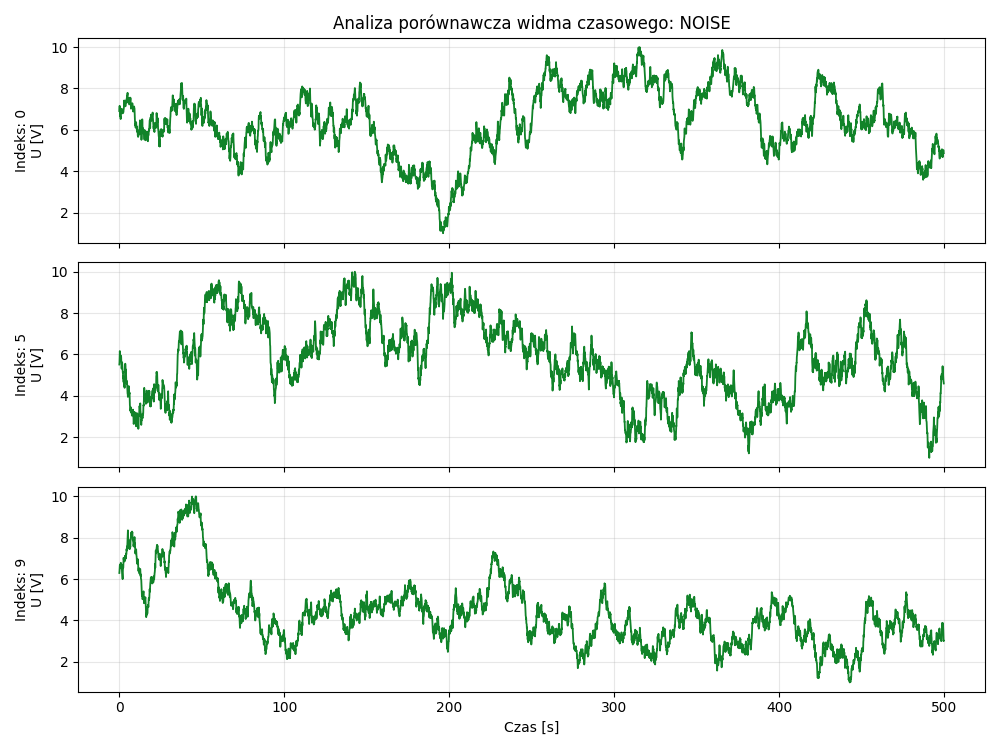

In [20]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.5, seed=42)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=0, n_noise=10)

Plotter.plot_indices(dataset['noise'], "noise", indices=[0, 5, 9])

# dataset_noisy = creator.create_noisy_dataset_copy()
# Plotter.plot_indices(dataset['noise'], "noise", indices=[0, 5, 9], signals_noisy=dataset_noisy['noise'], noise_level=creator.noise_level)

---

## **3. Transformata Fouriera**


Transformata Fouriera stanowi jeden z fundamentów współczesnego cyfrowego przetwarzania sygnałów, telekomunikacji oraz inżynierii dźwięku. Głównym założeniem analizy fourierowskiej jest teza, że każdy sygnał okresowy, spełniający warunki Dirichleta, można przedstawić w postaci nieskończonej sumy funkcji trygonometrycznych (sinusów i cosinusów) o różnych amplitudach, częstotliwościach i przesunięciach fazowych.
W klasycznym ujęciu ciągłym przekształcenie to mapuje sygnał z domeny czasu $t$ do ciągłej domeny częstotliwości $\omega$. Jednak w systemach mikroprocesorowych i komputerowych, gdzie operujemy na sygnałach spróbkowanych, konieczne jest zastosowanie aparatu matematycznego dostosowanego do ciągów dyskretnych.

### 3.1 **Dyskretna Transformata Fouriera (DFT)**

W przypadku analizy komputerowej sygnał ciągły poddawany jest próbkowaniu z częstotliwością $f_s$, w wyniku czego powstaje skończony ciąg próbek czasu $x[n]$ o długości $N$, gdzie $n = 0, 1, \dots, N-1$. Dla takiego sygnału definiuje się DFT, która przekształca skończony ciąg próbek czasu w skończony ciąg współczynników widmowych w dziedzinie częstotliwości $X[k]$. Matematyczny wzór prostej transformaty Fouriera zdefiniowany jest jako:
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} k n}$$
gdzie:

$x[n]$ – $n$-ta próbka sygnału wejściowego w dziedzinie czasu,

$X[k]$ – $k$-ty współczynnik widma w dziedzinie częstotliwości ($k = 0, 1, \dots, N-1$),

$N$ – całkowita liczba próbek sygnału,

$j$ – jednostka urojona ($j = \sqrt{-1}$).

Każdy wyznaczony współczynnik $X[k]$ jest liczbą zespoloną, którą można zapisać w postaci algebraicznej: $X[k] = Re(X[k]) + j \cdot Im(X[k])$.

**Interpretacja fizyczna współczynników widma:**
- Moduł (Amplituda): $|X[k]| = \sqrt{Re(X[k])^2 + Im(X[k])^2}$ reprezentuje udział (energię) składowej sinusoidalnej o częstotliwości powiązanej z indeksem $k$.
- Faza: Przesunięcie fazowe danej składowej określa się jako $\arg(X[k]) = \text{atan2}(Im(X[k]), Re(X[k]))$.
- Część rzeczywista i urojona: Część rzeczywista odpowiada za składowe kosinusoidalne, natomiast część urojona za składowe sinusoidalne.

### **3.2 Odwrotna Dyskretna Transformata Fouriera (IDFT)**

Transformacja Fouriera jest operacją w pełni odwracalną. Oznacza to, że dysponując kompletnym widmem częstotliwościowym $X[k]$, jesteśmy w stanie precyzyjnie odtworzyć pierwotny sygnał dyskretny w dziedzinie czasu. Służy do tego Odwrotna Dyskretna Transformata Fouriera, definiowana wzorem:

$$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] \cdot e^{j \frac{2\pi}{N} k n}$$

Wzór ten różni się od transformaty prostej zmianą znaku w wykładniku funkcji eksponencjalnej (co wynika ze zmiany kierunku obrotu wektora na płaszczyźnie zespolonej) oraz obecnością współczynnika skalującego $\frac{1}{N}$, który zapewnia zachowanie odpowiednich poziomów amplitudy sygnału po rekonstrukcji.

### **3.3 Transformata Fouriera w kompresji sygnałów**

Jednym z głównych zastosowań DFT/IDFT badanych w niniejszym projekcie jest kompresja stratna. Ponieważ wiele rzeczywistych sygnałów, w tym mowa czy muzyka, charakteryzuje się tzw. rzadkością widmową. Większość energii sygnału skupiona jest w niewielkiej liczbie dominujących współczynników $X[k]$.Proces kompresji polega na:
- Przejściu do domeny częstotliwości za pomocą prostej transformaty (DFT).
- Selekcji i zachowaniu jedynie $K$ najważniejszych prążków widma (np. o najwyższej energii lub przekraczających zadany próg błędu), podczas gdy pozostałe współczynniki są zerowane.
- Przeprowadzeniu rekonstrukcji (IDFT) na przyciętym widmie.

Efektywność takiego podejścia szacuje się poprzez analizę kompromisu pomiędzy stopniem redukcji danych (współczynnik kompresji) a wiernością rekonstrukcji, mierzoną wskaźnikami takimi jak błąd średniokwadratowy ($MSE$), błąd maksymalny ($Max\ Error$) czy współczynnik zniekształceń harmonicznych ($PRD$).

### **3.4. Metryki oceny jakości rekonstrukcji**


Zanim jednak przejdziemy do samych algorytmów, musimy zdefiniować matematyczne narzędzia, którymi będziemy mierzyli jakość i błędy rekonstrukcji sygnału po jego odtworzeniu.

Do oceny stopnia zniekształcenia sygnału po kompresji zaimplementowano klasę `SignalMetrics`. Wykorzystuje ona zestaw standardowych wskaźników jakościowych stosowanych w cyfrowym przetwarzaniu sygnałów (DSP):

* **Całkowita energia sygnału ($E$):** Suma kwadratów amplitudy próbek w dziedzinie czasu. Służy do weryfikacji bilansu energetycznego i wyznaczenia procentowej straty energii po kompresji.
$$E = \sum_{n=0}^{N-1} (y[n])^2$$

* **Błąd średniokwadratowy (MSE):** Mierzy średnią moc błędu rekonstrukcji. Jest bardzo czuły na większe odchyłki ze względu na podnoszenie różnic do kwadratu.
$$\text{MSE} = \frac{1}{N} \sum_{n=0}^{N-1} (y[n] - \hat{y}[n])^2$$

* **Pierwiastek błędu średniokwadratowego (RMSE):** Pierwiastek z MSE, dzięki czemu wynik ma tę samą jednostkę fizyczną co analizowany sygnał (np. Wolty, Ampery), co ułatwia bezpośrednią interpretację.
$$\text{RMSE} = \sqrt{\text{MSE}}$$

* **Maksymalny błąd bezwzględny ($\text{Max Error}$):** Wskazuje największą punktową, chwilową różnicę między oryginałem a rekonstrukcją. Pozwala sprawdzić, czy algorytm nie obciął kluczowych wartości szczytowych (pików).
$$\text{Max Error} = \max |y[n] - \hat{y}[n]|$$

* **Wskaźnik zniekształcenia PRD (*Percent Root-mean-square Difference*):** Kluczowa, znormalizowana metryka procentowa określająca globalny stopień zniekształcenia sygnału. Wartość 0% oznacza idealną rekonstrukcję. Jest niezależna od bezwzględnej skali amplitudy sygnału, co pozwala na porównywanie różnych przebiegów pomiarowych między sobą.
$$\text{PRD} = \sqrt{\frac{\sum_{n=0}^{N-1} (y[n] - \hat{y}[n])^2}{\sum_{n=0}^{N-1} (y[n])^2}} \cdot 100\%$$

Gdzie $y[n]$ to sygnał oryginalny, $\hat{y}[n]$ to sygnał zrekonstruowany, a $N$ to liczba próbek. W implementacji programowej przed obliczeniami nakładana jest operacja `np.real()`, która bezpiecznie odrzuca mikro-części urojone współczynników (rzędu $10^{-15}$), będące efektem ubocznym numerycznego zaokrąglania operacji zmiennoprzecinkowych w IDFT.

### **3.5 Opis wykorzystywanych algorytmów transformaty Fouriera**

W tym projekcie wykorzystaliśmy dwa silniki transformaty Fouriera. Pierwszym z nich była nasza własna implementacja dyskretnej transformaty Fouriera. W większej częsci wykrozystywana była jednak implementacja transformaty Fouriera z biblioteki *numpy*. Implementacja biblioteczna przyśpieszyła wykonywanie dokładnych testów oraz zapewniła stabilność pracy.

#### **3.5.1 Własna implementacja**

Prezentowana klasa DiscreteFourier stanowi obiektową powłokę grupującą statyczne metody przeznaczone do numerycznej analizy widmowej sygnałów dyskretnych. Implementacja nie korzysta z gotowych algorytmów bibliotecznych (takich jak numpy.fft), lecz bezpośrednio odwzorowuje definicje matematyczne DFT, IDFT oraz algorytmy progowania widma za pomocą zoptymalizowanych operacji macierzowych w pakiecie NumPy.

**Metoda transform**

Metoda transform realizuje przejście z dziedziny czasu do dziedziny częstotliwości za pomocą Dyskretnej Transformaty Fouriera ($DFT$):
```python
@staticmethod
    def transform(t_vec, y_vec):
        """
        Oblicza Dyskretną Transformatę Fouriera (DFT) jako funkcja statyczna.
        
        Args:
            t_vec (np.ndarray): Wektor czasu (np. linspace).
            y_vec (np.ndarray): Wartości sygnału (tej samej długości co t_vec).
            
        Returns:
            tuple: (freq_vec, f_k_vec) - wektor częstotliwości w Hz oraz zespolone widmo.
        """
        N = len(t_vec)
        
        # Obliczamy krok czasu (dt) i częstotliwość próbkowania (fs) lokalnie
        dt = t_vec[1] - t_vec[0]
        fs = 1.0 / dt
        
        # Generujemy indeksy k (częstotliwości) i n (czas)
        k = np.arange(N)
        n = np.arange(N)
        
        # Macierz wykładników dla DFT: exp(-j * 2pi * k * n / N)
        K, N_idx = np.meshgrid(k, n, indexing='ij')
        W = np.exp(-2j * np.pi * K * N_idx / N)
        
        # Sumowanie (iloczyn macierzowy): F_k = suma(y_n * W_kn)
        f_k_vec = np.dot(W, y_vec)
        
        # Obliczamy wektor częstotliwości w Hz
        freq_vec = k * (fs / N)
        
        return freq_vec, f_k_vec
```
- Wyznaczenie parametrów próbkowania: Na podstawie wektora czasu t_vec program wyznacza okres próbkowania $dt$, a następnie oblicza częstotliwość próbkowania $f_s = \frac{1}{dt}$.
- Wektoryzacja i siatka dwuwymiarowa: Zamiast kosztownych obliczeniowo pętli zagnieżdżonych for, algorytm wykorzystuje funkcję np.meshgrid do stworzenia dwuwymiarowej siatki indeksów częstotliwości $k$ oraz czasu $n$. Pozwala to na jednoczesne obliczenie całej macierzy rotacji $W$, której elementy odpowiadają jądru przekształcenia:$$W_{k,n} = e^{-j \frac{2\pi}{N} k n}$$
- Iloczyn macierzowy: Wyznaczenie zespolonych współczynników widma f_k_vec ($X[k]$) odbywa się poprzez operację iloczynu skalarnego np.dot macierzy zespolonej $W$ z wektorem dyskretnych próbek sygnału $y[n]$.
- Skalowanie osi częstotliwości: Metoda generuje również wektor freq_vec, mapując abstrakcyjne numery prążków $k$ na fizyczną częstotliwość wyrażoną w hercach ($Hz$), zgodnie z zależnością $f = k \cdot \frac{f_s}{N}$.

**Metoda invers_transform**

Metoda inverse_transform odpowiada za powrót z dziedziny częstotliwości do dziedziny czasu przy użyciu Odwrotnej Dyskretnej Transformaty Fouriera
```python
@staticmethod
    def inverse_transform(f_omega_vec):
        """
        Odtwarza sygnał na podstawie współczynników f_k_vec (IDFT).
        """
        N = len(f_omega_vec)
        k = np.arange(N)
        n = np.arange(N)
        
        # Macierz wykładników dla IDFT: exp(+j * 2pi * k * n / N)
        K, N_idx = np.meshgrid(k, n, indexing='ij')
        W_inv = np.exp(2j * np.pi * K * N_idx / N)
        
        # Sumowanie i skalowanie przez 1/N
        # n-ty element to suma po k
        res = np.dot(W_inv.T, f_omega_vec) / N
        
        return res.real
```

- Jądro transformacji odwrotnej: Podobnie jak w przypadku prostej transformaty, generowana jest macierz wykładników zespolonych W_inv. Kluczową różnicą matematyczną jest zmiana znaku w argumencie funkcji wykładniczej na dodatni ($\exp(+2j \dots)$).
- Mnożenie i transpozycja: Rekonstrukcja realizowana jest poprzez pomnożenie transponowanej macierzy bazowej W_inv.T przez wektor współczynników zespolonych f_omega_vec. Wynik poddawany jest skalowaniu (dzieleniu) przez całkowitą liczbę próbek $N$.
- Ekstrakcja części rzeczywistej: Z powodu drobnych zaokrągleń numerycznych operacji na liczbach zmiennopozycyjnych wyższych rzędów (float64), wynik transformacji odwrotnej może posiadać zaniedbywalnie małą, niezerową część urojoną (np. rzędu $10^{-15}j$). Funkcja zwraca wyłącznie część rzeczywistą .real, przywracając sygnał do jego oryginalnej, rzeczywistej postaci.

**Metoda trim_spectrum**

Metoda trim_spectrum realizuje algorytm redukcji informacji (kompresji) opartej na kryterium selekcji magnitudy współczynników.

```python
@staticmethod
    def trim_spectrum(f_omega_vec, k):
        """
        Zeruje wszystkie współczynniki poza K największymi.
        """
        magnitudes = np.abs(f_omega_vec)
        # Znajdujemy próg dla k-tej największej wartości
        if k >= len(f_omega_vec):
            return f_omega_vec
        
        threshold_val = np.sort(magnitudes)[-k]
        
        f_trimmed = np.zeros_like(f_omega_vec, dtype=complex)
        mask = magnitudes >= threshold_val
        f_trimmed[mask] = f_omega_vec[mask]
        
        return f_trimmed
```

- Obliczenie modułu: Algorytm wyznacza wektor amplitud (magnitud) magnitudes za pomocą funkcji np.abs(), obliczając moduł z liczb zespolonych.
- Dynamiczne wyznaczenie progu odcięcia: Warunek instrukcji warunkowej zabezpiecza kod przed błędem indeksowania w sytuacji, gdy parametr $K$ przewyższa rozmiar widma. Poprzez posortowanie tablicy amplitud rosnąco (np.sort), algorytm identyfikuje wartość progową threshold_val znajdującą się na pozycji [-k] (jest to $K$-ta największa amplituda w sygnale).
- Filtrowanie i maskowanie: Tworzona jest pusta (wypełniona zerami) tablica zespolona f_trimmed o identycznym rozmiarze. Następnie za pomocą techniki maskowania logicznego (magnitudes >= threshold_val), do nowej tablicy przepisywane są wyłącznie te współczynniki fourierowskie, których amplituda jest większa lub równa wyznaczonemu progowi. Pozostałe składowe widma pozostają wyzerowane, co stanowi istotę algorytmu kompresji stratnej.

#### **3.5.2 Transfomata Fouriera z biblioteki Numpy**

Biblioteka NumPy oferuje dedykowany moduł `numpy.fft`, który w środowisku programistycznym stanowi standard do szybkiej i zoptymalizowanej analizy częstotliwościowej. W projekcie wykorzystywaliśmy dwie metody: `np.fft.fft` oraz `np.fft.ifft` do obliczania standardowej, zespolonej transformaty prostej i odwrotnej. Ponieważ sygnały rzeczywiste (takie jak dźwięk czy odczyty z czujników) posiadają symetryczne widmo, programiści bardzo często sięgają po ich zoptymalizowane wersje – `np.fft.rfft` oraz `np.fft.irfft`. Metody te operują wyłącznie na częstotliwościach dodatnich, co pozwala na dwukrotne przyspieszenie obliczeń oraz redukcję zużycia pamięci. 

#### **3.5.3 Porównanie implementacji własnej z biblioteką Numpy**

Porównanie autorskiego silnika transformaty Fouriera z podejściem z biblioteki Numpy oparto na sygnale *APRBS*. Struktura widmowa zostaje ograniczona do 100 dominujących składowych, a na podstawie przyciętego wektora realizowana jest matematyczna rekonstrukcja sygnału do domeny czasu. Na wykresach pokazano porównanie widm przed i po rekonstrukcji, natomiast tabele pokazują wskaźniki rekonstrukcji.

Choć oba algorytmy realizują to samo fundamentalne zadanie matematyczne – czyli Dyskretną Transformatę Fouriera (DFT) – to różnią się one podejściem programistycznym, stopniem optymalizacji oraz sposobem prezentacji danych wyjściowych. W obu algorytmach wykorzystywaliśmy funkcję obliczające pełne, definicyjne widmo sygnału. Oznacza to, że w wektorze wyjściowym nie obcinamy lustrzanego odbicia . Wynikowy wektor współczynników ma dokładnie taką samą długość $N$ jak wektor próbek czasowych, zachowując pełną symetrię wokół częstotliwości Nyquista.

Znaczącą różnicę można zauważyć w kontekście złożoności obliczeniowej. Implementacja autorska bazuje na bezpośrednim mnożeniu macierzy (jądra transformacji) przez wektor sygnału. Choć dzięki operacjom np.meshgrid i np.dot kod został w pełni zwektoryzowany (unika wolnych pętli for w Pythonie), to jego złożoność obliczeniowa nadal wynosi $O(N^2)$. Dla bardzo długich sygnałów algorytm ten staje się barierą wydajnościową.
Implementacja NumPy pod spodem wykorzystuje zaawansowany i silnie zoptymalizowany algorytm Szybkiej Transformaty Fouriera (FFT). Zmniejsza on złożoność obliczeniową do poziomu $O(N \log N)$. Różnica ta jest gigantyczna.

**Porównanie działania obu implementacji**

Generowanie NOISE        :   0%|          | 0/1 [00:00<?, ?it/s]

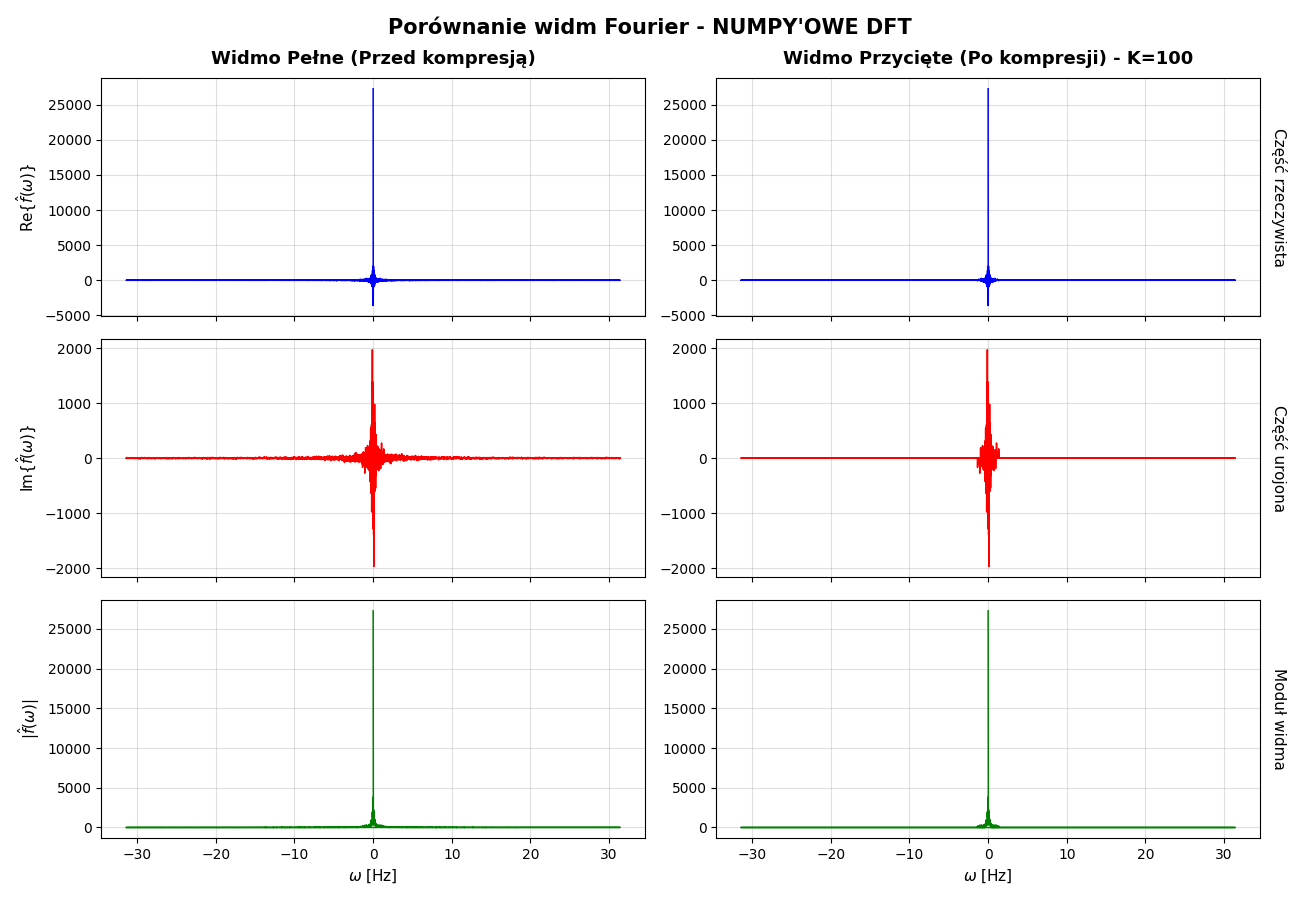

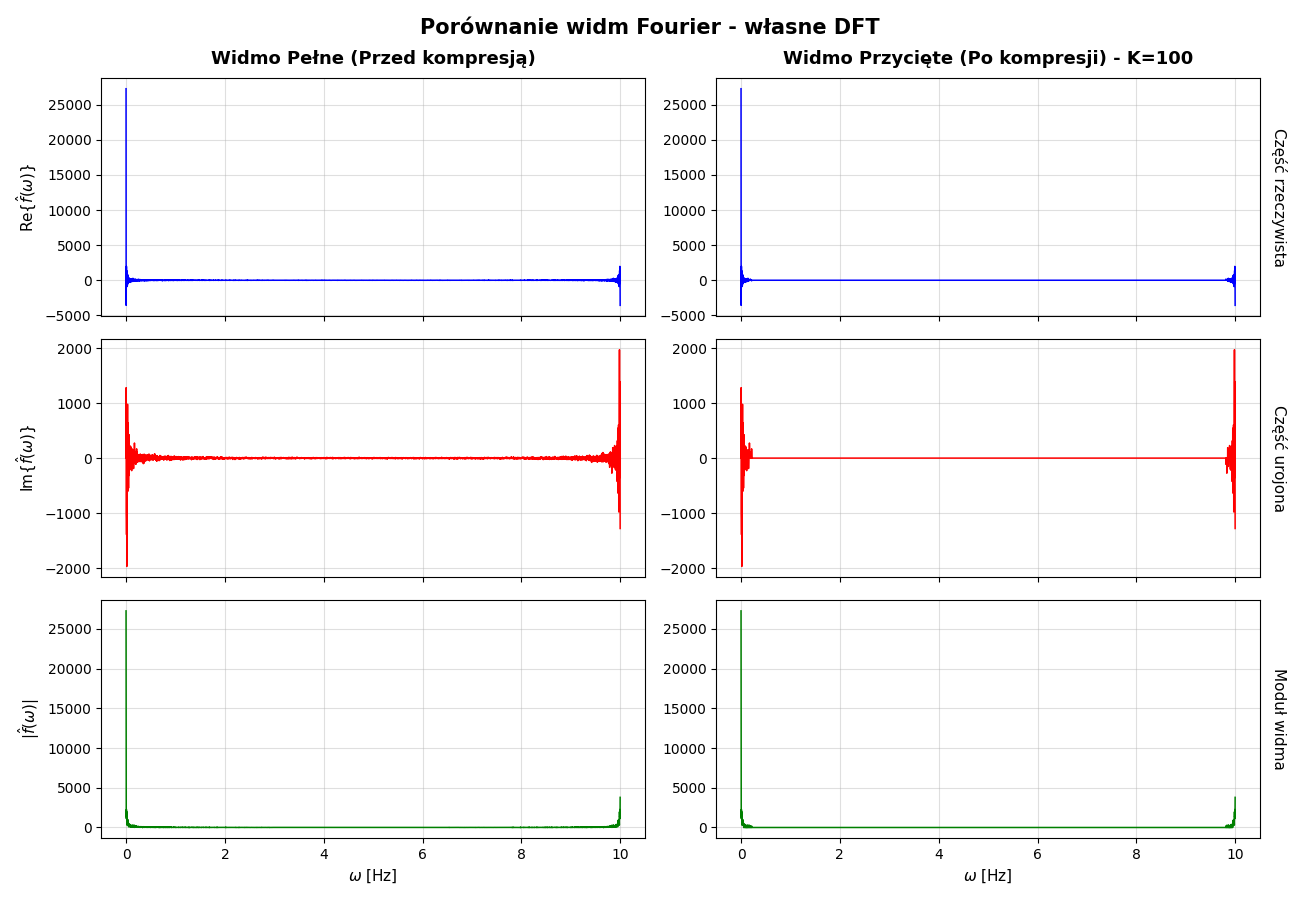

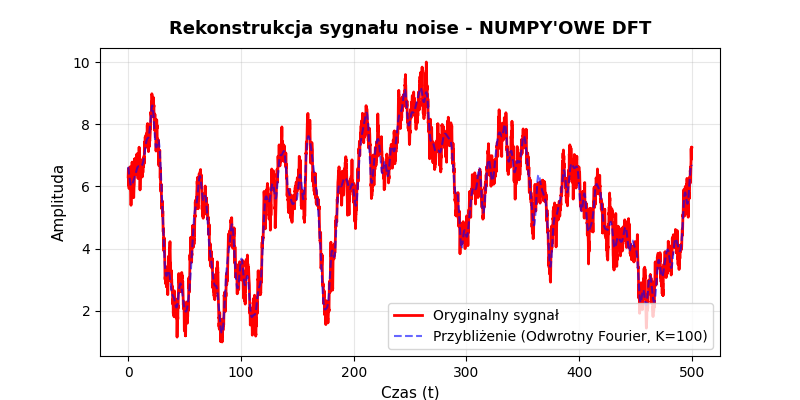

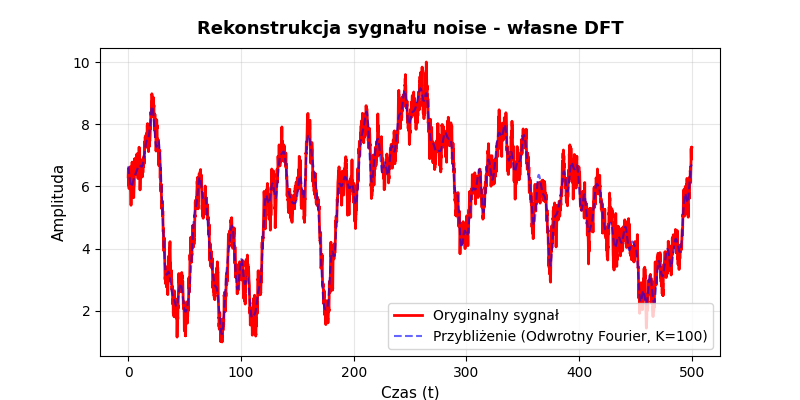

Parametr / Wskaźnik jakości,Wartość
Energia oryginału (w dziedzinie czasu),166068.6132
Energia po rekonstrukcji (w dziedzinie czasu),165424.1296
Procentowa strata energii,0.39%
MSE,0.1275
RMSE,0.3571
MAX ERROR,1.2292
Wskaźnik zniekształcenia PRD,6.20%


Parametr / Wskaźnik jakości,Wartość
Energia oryginału (w dziedzinie czasu),166068.6132
Energia po rekonstrukcji (w dziedzinie czasu),165434.6162
Procentowa strata energii,0.38%
MSE,0.1268
RMSE,0.3561
MAX ERROR,1.2596
Wskaźnik zniekształcenia PRD,6.18%


In [21]:
from DatasetCreator import DatasetCreator
from Plotter import Plotter 
from Fourier import DiscreteFourier
from SignalMetrics import SignalMetrics
from TableRenderer import ReportTableRenderer
import numpy as np


creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=0, n_noise=1)

# Wybierz kategorię sygnału do analizy
signal_type = 'noise'  # Wybierz kategorię sygnału: 'aprbs', 'multisine', 'noise'
signal = dataset[signal_type][0] 

k=100  # Liczba współczynników do zachowania w widmie

# ------ NUMPY'OWA IMPLEMENTACJA DFT ------

# Transformacja Fouriera
f_omega_numpy = np.fft.fft(signal.y)
freqs = np.fft.fftfreq(len(signal.y), d=(signal.t[1] - signal.t[0]))
omega_numpy = 2 * np.pi * freqs

# Przycinanie widma na podstawie k największych wartości
magnitudes = np.abs(f_omega_numpy)
threshold_val = np.sort(magnitudes)[-k]  # Ustalamy próg na podstawie k-tej największej wartości
f_trimmed_np = np.where(magnitudes >= threshold_val, f_omega_numpy, 0)

# Rekonstrukcja sygnału z przyciętego widma
y_reconstructed_np = np.fft.ifft(f_trimmed_np, n=len(signal.y)).real

# ------ WŁASNA IMPLEMENTACJA DFT ------

# Transformacja Fouriera
omega_vec, f_omega_vec = DiscreteFourier.transform(signal.t, signal.y)

# Przycinanie widma na podstawie k największych wartości
f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=k)

# Rekonstrukcja sygnału z przyciętego widma
y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)

# ------  WYKRESY PORÓWNAWCZE ------

Plotter.plot_fourier_comparison_widma(omega_numpy, f_omega_numpy, f_trimmed_np, K=k, title="Porównanie widm Fourier - NUMPY'OWE DFT")
Plotter.plot_fourier_comparison_widma(omega_vec, f_omega_vec, f_trimmed, K=k, title="Porównanie widm Fourier - własne DFT")

Plotter.plot_fourier_comparison(signal.t, signal.y, y_reconstructed_np, K=k, title=f"Rekonstrukcja sygnału {signal_type} - NUMPY'OWE DFT")
Plotter.plot_fourier_comparison(signal.t, signal.y, y_reconstructed, K=k, title=f"Rekonstrukcja sygnału {signal_type} - własne DFT")

# ------ METRYKI WIERNOŚCI I ENERGII ------

# Automatyczne wyliczenie pełnego zestawu metryk wierności i energii
metrics_results = {
    'własne DFT': SignalMetrics.evaluate_reconstruction(signal.y, y_reconstructed),
    'NUMPY\'OWE DFT': SignalMetrics.evaluate_reconstruction(signal.y, y_reconstructed_np)
}

# Konstrukcja struktury raportu tabelarycznego
headers = ["Parametr / Wskaźnik jakości", "Wartość"]

# Wyświetlenie tabel
for name, metrics in metrics_results.items():
    rows = []
    for key, val in metrics.items():
        if "strata" in key.lower():
            formatted_val = f"{val:.2f}%"
        elif "prd" in key.lower():
            formatted_val = f"{val:.2f}%"
        else:
            formatted_val = f"{val:.4f}" if isinstance(val, float) else str(val)
        
        rows.append([key, formatted_val])

    ReportTableRenderer.render(
        title=f"Kompletny raport wierności sygnału {signal_type.upper()} dla {name} (K = {k})",
        headers=headers,
        rows=rows
    )


---

## **4. Strategie kompresji**

W tej sekcji zajmiemy się kompresją sygnału w dziedzinie częstotliwości. Cała sztuka polega na tym, żeby wyrzucić (wyzerować) te składowe widma, które niewiele wnoszą, i zostawić tylko te najważniejsze. Dzięki temu wektor częstotliwości staje się rzadki (ma dużo zer), co pozwala mocno "odchudzić" dane, zachowując kluczowe cechy sygnału.

Do wyznaczenia optymalnego punktu odcięcia współczynników przetestujemy dwa różne podejścia adaptacyjne:

1. **Analiza energii (Kryterium Energetyczne):** Podejście szybkie, działające w dziedzinie częstotliwości. Sortujemy prążki od najsilniejszego i na podstawie twierdzenia Parsevala zostawiamy tylko tyle współczynników, ile potrzeba, by zachować np. 99% całkowitej energii sygnału.

2. **Analiza dokładności (Kryterium Fidelity):** Podejście dokładniejsze, działające w dziedzinie czasu. Uruchamiamy szybki algorytm bisekcji (wyszukiwania binarnego), który krok po kroku sprawdza rzeczywisty błąd rekonstrukcji sygnału (MSE lub błąd maksymalny) i szuka minimalnego zestawu prążków, przy którym błąd nie przekracza zadanej tolerancji.


### **4.1. Algorytm oparty na analizie energii**

Kompresja sygnałów w dziedzinie częstotliwości z wykorzystaniem kryterium energetycznego opiera się na selektywnej eliminacji składowych spektralnych o relatywnie niskiej amplitudzie, których udział w całkowitym bilansie mocy sygnału jest pomijalny. Algorytm ten wykorzystuje fakt, że w przypadku większości sygnałów deterministycznych oraz sygnałów pomiarowych obciążonych szumem, informacja użyteczna skupiona jest w niewielkiej liczbie dominujących harmonicznych, podczas gdy składowe wysokoczęstotliwościowe oraz fluktuacje losowe niosą ze sobą minimalny ładunek energetyczny. Poprzez identyfikację i zachowanie wyłącznie kluczowych prążków spektralnych, możliwe jest uzyskanie wysokiego stopnia kompresji danych przy jednoczesnym zachowaniu pożądanego profilu sygnału pierwotnego.



#### ***4.1.1 Podstawa matematyczna i kryteria błędu***


Podstawą matematyczną tej metody jest twierdzenie Parsevala, które mówi, że całkowita energia sygnału obliczona w dziedzinie czasu jest równa całkowitej energii jego transformaty w dziedzinie częstotliwości:

$$\sum_{n=0}^{N-1} |y[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |Y[k]|^2$$

Gdzie:
* $y[n]$ — próbki sygnału w dziedzinie czasu,
* $Y[k]$ — zespolone współczynniki uzyskane z dyskretnej transformaty Fouriera (DFT),
* $N$ — całkowita liczba próbek sygnału (wymiar przestrzeni transformacji).

Ponieważ widmo sygnałów rzeczywistych cechuje się symetrią sprzężoną wokół częstotliwości Nyquista, algorytm operuje na modułach wszystkich współczynników $|Y[k]|$ w pełnym zakresie pasma $[0, f_s)$. Parametr $f_s$ oznacza częstotliwość próbkowania sygnału wejściowego (wyrażoną w hercach), która definiuje liczbę próbek rejestrowanych w ciągu sekundy. W procesie sortowania spektralnego symetryczne pary dominujących prążków są naturalnie pozycjonowane obok siebie. Pozwala to na bezbłędne zachowanie globalnego bilansu energetycznego według twierdzenia Parsevala, bez konieczności manualnej redukcji wymiarowości wektora częstotliwości czy odrębnego przetwarzania widma jednostronnego.



#### ***4.1.2. Przebieg procedury kompresji***



W celu numerycznej weryfikacji algorytmu, w strukturze skryptu testowego wydzielono trzy główne etapy przetwarzania sygnału częstotliwościowego. Poniższy opis szczegółowo definiuje operacje realizowane w każdym z kluczowych punktów programu:

1. **Wyznaczenie widma autorską metodą:** W tym kroku za pomocą statycznej metody klasy `DiscreteFourier.transform()` przetwarzane są wektory czasu (`signal.t`) oraz wartości sygnału (`signal.y`), a następnie wyznacza dyskretną transformatę Fouriera za pomocą metody `transform()`. Wynikiem działania są dwa wektory: `omega_vec` (zawierający fizyczne częstotliwości wyrażone w Hz) oraz `f_omega_vec` reprezentujący pełne, obustronne widmo zespolone o długości równej liczbie próbek wejściowych $N$.

2. **Analiza rozkładu energii:** Etap ten odpowiada za wyznaczenie optymalnej liczby współczynników spektralnych $K$ na podstawie zdefiniowanego przez użytkownika kryterium zachowania energii (`energy_threshold`). Wewnętrzna logika metody `analyze_energy_distribution` realizowana jest poprzez następujące kroki cząstkowe:
   * 2.1. **Obliczenie gęstości widmowej mocy:** Konwersja zespolonych współczynników $Y[k]$ na wartości rzeczywiste określające moc prążków poprzez obliczenie kwadratu ich modułu (`np.abs(coeffs)**2`).

   * 2.2. **Wyznaczenie energii całkowitej widma:** Obliczenie sumarycznej energii w dziedzinie częstotliwości z uwzględnieniem skalowania przez długość sygnału $N$. Wartość ta (`total_energy_freq`) stanowi bezpośredni odpowiednik energii czasowej sygnału pierwotnego.

   * 2.3. **Sortowanie spektralne współczynników:** Uszeregowanie wszystkich składowych mocy od wartości największej do najmniejszej. Krok ten pozwala na natychmiastową lokalizację dominujących harmonicznych sygnału.

   * 2.4. **Wyznaczenie profilu akumulacji energii:** Program tworzy wektor, który działa jak "licznik" zgromadzonej energii (`np.cumsum`). Idąc od najsilniejszego prążka do najsłabszego, algorytm dodaje energię kolejnych współczynników i sprawdza, jaki procent energii całkowitej już zebrał (wartość ta rośnie od 0 do 1, czyli do 100%).

   * 2.5. **Ekstrakcja indeksu granicznego $K$:** Wykorzystanie operacji logicznej i funkcji poszukiwania pierwszego indeksu spełniającego warunek brzegowy (`np.argmax(...) + 1`). Zwracana wartość `k_threshold` definiuje precyzyjnie, ile największych prążków widma należy zachować, aby nie przekroczyć narzuconego limitu strat.

3. **Kompresja (Przycięcie widma) i rekonstrukcja sygnału:** W ostatniej fazie wyznaczona wartość `k_threshold` przekazywana jest wraz z bazowym widmem do metody statycznej `DiscreteFourier.trim_spectrum()`. Funkcja ta wyznacza próg amplitudy dla $K$-tego największego współczynnika, a następnie tworzy maskę logiczną, która zachowuje nienaruszone prążki dominujące, a wszystkie pozostałe, mało istotne energetycznie składowe (szum, fluktuacje) nadpisuje wartością zero. Skompresowany w ten sposób wektor częstotliwości (`f_trimmed`) trafia do metody `DiscreteFourier.inverse_transform()`, gdzie za pomocą algorytmu IDFT następuje synteza czysto rzeczywistego sygnału wyjściowego `y_reconstructed`.

Efektem działania algorytmu jest drastyczne zredukowanie liczby niezerowych elementów w wektorze częstotliwości. Przekłada się to bezpośrednio na wysoki stopień kompresji danych przy jednoczesnym ścisłym, matematycznym kontrolowaniu dopuszczalnych strat informacji, co potwierdza końcowy bilans energetyczny sygnału skompresowanego (`e_time_reconstructed`).

#### ***4.1.3. Kod***

**Analiza energi sygnałów APRBS, Multisine i Filtered Noise**

W trakcie wykonywania tego kodu realizowany jest proces potokowego przetwarzania, kompresji i ewaluacji jakościowej trzech typów sygnałów. Dla każdego z nich, na podstawie surowych próbek czasowych, wyznaczana jest struktura częstotliwościowa, a następnie analizowany jest skumulowany rozkład energii w widmie w celu odcięcia $K$ najważniejszych składowych gwarantujących zachowanie $99{,}9\%$ energii tła. 

Generowanie APRBS        :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/1 [00:00<?, ?it/s]


[URUCHOMIENIE] Rozpoczęto analizę energetyczną dla typu: APRBS


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Dystrybucja Energii (Widmo)
[Konfiguracja] Zadany próg energii,99.90%
[Wynik selekcji] Wymagana liczba składowych (K),534
Energia oryginału (w dziedzinie częstotliwości),199496.0184
Energia oryginału (w dziedzinie czasu),199496.0184
Energia po rekonstrukcji (w dziedzinie czasu),199296.6017
Procentowa strata energii,0.10%
MSE,0.0398
RMSE,0.1995
MAX ERROR,3.0271


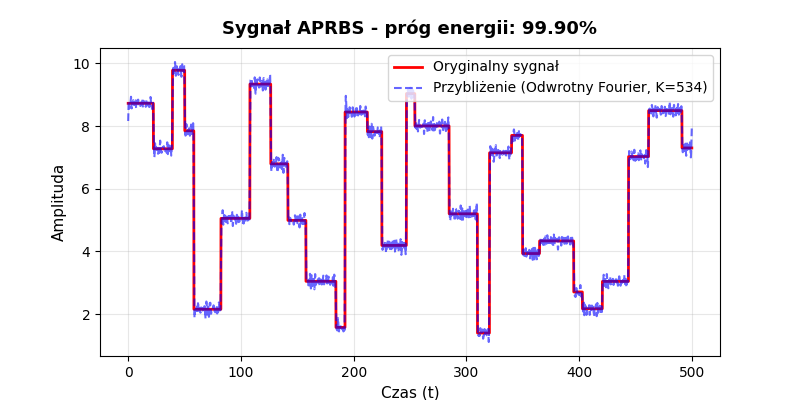


[URUCHOMIENIE] Rozpoczęto analizę energetyczną dla typu: MULTISINE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Dystrybucja Energii (Widmo)
[Konfiguracja] Zadany próg energii,99.90%
[Wynik selekcji] Wymagana liczba składowych (K),27
Energia oryginału (w dziedzinie częstotliwości),159777.0523
Energia oryginału (w dziedzinie czasu),159777.0523
Energia po rekonstrukcji (w dziedzinie czasu),159617.5161
Procentowa strata energii,0.10%
MSE,0.0319
RMSE,0.1786
MAX ERROR,1.6070


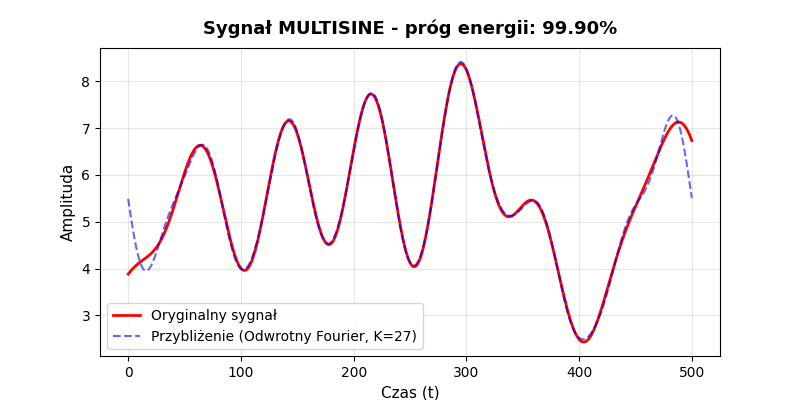


[URUCHOMIENIE] Rozpoczęto analizę energetyczną dla typu: NOISE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Dystrybucja Energii (Widmo)
[Konfiguracja] Zadany próg energii,99.90%
[Wynik selekcji] Wymagana liczba składowych (K),243
Energia oryginału (w dziedzinie częstotliwości),214293.1608
Energia oryginału (w dziedzinie czasu),214293.1608
Energia po rekonstrukcji (w dziedzinie czasu),214079.1335
Procentowa strata energii,0.10%
MSE,0.0428
RMSE,0.2069
MAX ERROR,1.5157


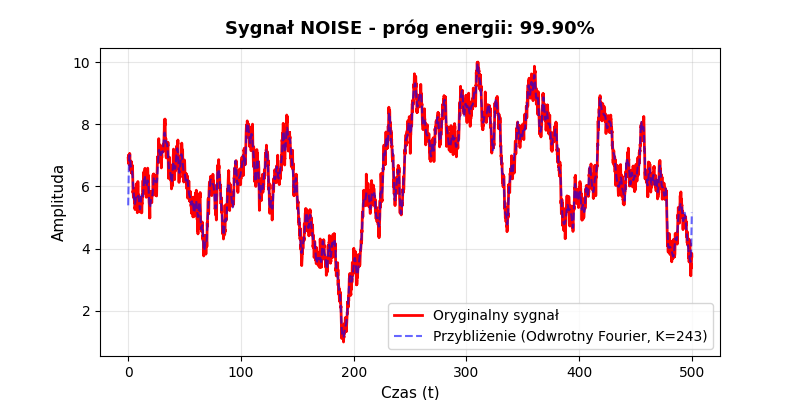


[SUKCES] Wszystkie sygnały zostały pomyślnie przetworzone pod kątem kryterium energetycznego!


In [21]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Fourier import DiscreteFourier
from EnergyAnalyzer import EnergyAnalyzer
from Plotter import Plotter
from tabulate import tabulate
from TableRenderer import ReportTableRenderer
from SignalMetrics import SignalMetrics  

# Inicjalizacja generatora i utworzenie zbioru danych
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
dataset = creator.create_dataset(n_aprbs=1, n_multisine=1, n_noise=1)

# Lista wszystkich rodzajów sygnałów do sekwencyjnej analizy energetycznej
signal_types = ['aprbs', 'multisine', 'noise']

# Globalny próg zachowania energii (99.9%)
energy_threshold = 0.999

# ==================================================================================
# GŁÓWNA PĘTLA PRZETWARZANIA ENERGETYCZNEGO
# ==================================================================================
for signal_type in signal_types:
    print(f"\n[URUCHOMIENIE] Rozpoczęto analizę energetyczną dla typu: {signal_type.upper()}")
    
    # Bezpieczne pobranie pierwszego sygnału z danej kategorii
    signal = dataset[signal_type][0]

    # ------------------------------------------------------------------------------
    # KROK 1: Wyznaczenie widma autorską metodą Fouriera
    omega_vec, f_omega_vec = DiscreteFourier.transform(signal.t, signal.y)

    # KROK 2: Analiza rozkładu energii - wyznaczenie progu K dla eth = 99.9%
    results_dsc = EnergyAnalyzer.analyze_energy_distribution(
        f_omega_vec, N=len(signal.y), threshold=energy_threshold
    )
    
    k_threshold = results_dsc['k_threshold']

    # KROK 3: Kompresja i rekonstrukcja sygnału na podstawie odciętego widma
    f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=k_threshold)
    y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)
    # ------------------------------------------------------------------------------

    # Automatyczne wyliczenie pełnego zestawu metryk wierności i energii
    metrics_results = SignalMetrics.evaluate_reconstruction(signal.y, y_reconstructed)

    # Konstrukcja struktury raportu tabelarycznego
    headers = ["Parametr / Wskaźnik jakości", "Wartość"]

    # Sekcja A: Założenia eksperymentu, selekcja K oraz energia tła częstotliwościowego
    rows = [
        ["[Konfiguracja] Tryb analizy błędu", "Dystrybucja Energii (Widmo)"],
        ["[Konfiguracja] Zadany próg energii", f"{energy_threshold * 100:.2f}%"],
        ["[Wynik selekcji] Wymagana liczba składowych (K)", f"{k_threshold}"],
        ["Energia oryginału (w dziedzinie częstotliwości)", f"{results_dsc['total_energy_freq']:.4f}"],
    ]

    # Sekcja B: Automatyczne dołączenie wszystkich metryk dynamicznych z formatowaniem %
    for key, val in metrics_results.items():
        if "strata" in key.lower():
            formatted_val = f"{val:.2f}%"
        elif "prd" in key.lower():
            formatted_val = f"{val:.2f}%"
        else:
            formatted_val = f"{val:.4f}" if isinstance(val, float) else str(val)
            
        rows.append([key, formatted_val])

    # Wyświetlenie zintegrowanej, nowoczesnej tabeli pastelowej w notebooku
    ReportTableRenderer.render(
        title=f"Kompletny raport wierności i energii sygnału {signal_type.upper()} (K = {k_threshold})",
        headers=headers,
        rows=rows
    )

    # Wizualizacja porównania widm i rekonstrukcji w dedykowanym oknie
    Plotter.plot_fourier_comparison(
        signal.t, 
        signal.y, 
        y_reconstructed, 
        K=k_threshold, 
        title=f"Sygnał {signal_type.upper()} - próg energii: {energy_threshold*100:.2f}%"
    )

print("\n[SUKCES] Wszystkie sygnały zostały pomyślnie przetworzone pod kątem kryterium energetycznego!")


### **4.2 Algorytm oparty na analizie dokładności (MSE / Max Error):**


Alternatywnym podejściem do kompresji spektralnej jest algorytm adaptacyjny sterowany kryterium wierności odwzorowania sygnału w dziedzinie czasu (ang. *Fidelity Criteria*). W przeciwieństwie do metody energetycznej, która analizuje strukturę widma w sposób globalny i statyczny, podejście wiernościowe bezpośrednio minimalizuje błędy powstałe w wyniku obcięcia bazy ortogonalnej, monitorując jakość rekonstrukcji w sposób iteracyjny.



#### ***4.2.1 Podstawa matematyczna i kryteria błędu***



Algorytm realizuje proces optymalizacji poszukujący minimalnej liczby składowych częstotliwościowych $K$, dla których błąd odwzorowania sygnału nie przekracza zadanego progu tolerancji $\epsilon$. W zależności od założeń aplikacyjnych, w strukturze klasy `FidelityAnalyzer` zaimplementowano dwa alternatywne tryby pracy (wskaźniki jakości):

1. **Błąd średniokwadratowy (MSE):** Kryterium to określa średnią energię błędu w całym horyzoncie czasowym. Pozwala na optymalizację globalnego kształtu sygnału, dopuszczając lokalne, szpilkowe odchyłki:
$$\text{MSE} = \frac{1}{N} \sum_{n=0}^{N-1} \left( y[n] - \hat{y}[n] \right)^2 \le \epsilon$$

2. **Błąd maksymalny ($\text{Max Error}$):** Kryterium o charakterze reżimowym, które bezwzględnie limituje największą chwilową odchyłkę amplitudy. Jest kluczowe w układach, gdzie lokalne zniekształcenie sygnału (np. ucięcie wartości szczytowej) mogłoby zafałszować interpretację fizyczną danych:
$$\text{Max Error} = \max_{0 \le n < N} |y[n] - \hat{y}[n]| \le \epsilon$$

Gdzie $y[n]$ oznacza sygnał oryginalny o długości $N$ próbek, natomiast $\hat{y}[n]$ to sygnał testowy, rekonstruowany dynamicznie na podstawie $k$ dominujących prążków widmowych.



#### ***4.2.2. Przebieg procedury kompresji***



Klasyczna, zachłanna implementacja tego podejścia wiąże się z drastycznym wzrostem złożoności obliczeniowej. Wyznaczenie błędu w dziedzinie czasu wymaga wykonania odwrotnej dyskretnej transformaty Fouriera (IDFT) w każdym kroku pętli. Przy złożoności pojedynczej transformaty równej $\mathcal{O}(N^2)$ i przeszukiwaniu liniowym, całkowita teoretyczna złożoność algorytmu adaptacyjnego wynosiłaby $\mathcal{O}(N^3)$, co przy długości sygnału $N = 5000$ próbek prowadzi do wykonania miliardów operacji zmiennoprzecinkowych i paraliżu wydajnościowego środowiska wykonawczego.

W celu zachowania autonomii kodu (nieaktywna flaga `use_numpy=False`) przy jednoczesnym zapewnieniu wysokiej wydajności numerycznej, w metodzie `FidelityAnalyzer.analyze_by_error` zastosowano **optymalizację poprzez prekalkulację bazy transformacji** oraz **logarytmiczne wyszukiwanie binarne**. 

W strukturze skryptu testowego wydzielono trzy główne etapy przetwarzania:

1. **Wyznaczenie widma pełnego metodą statyczną:** W pierwszym kroku za pomocą statycznej metody `DiscreteFourier.transform()` przetwarzane są wektory czasu (`signal.t`) oraz wartości sygnału (`signal.y`). Wynikiem działania funkcji są dwa wektory: `omega_vec` (fizyczne częstotliwości w Hz) oraz `f_omega_vec` (pełne, obustronne widmo zespolone o długości równej liczbie próbek wejściowych $N$). Wektor ten stanowi bazę wejściową dla analizatora wierności.

2. **Iteracyjna analiza wierności (Klasa `FidelityAnalyzer`):** Wyznaczony wektor współczynników o długości $N$ oraz sygnał źródłowy przekazywane są do metody statycznej `FidelityAnalyzer.analyze_by_error()`. Wewnętrzna struktura tej metody realizuje zoptymalizowaną pętlę wyszukiwania binarnego (bisekcji), wykonując następujące kroki funkcjonalne:
   * 2.1. **Sortowanie spektralne współczynników:** Algorytm oblicza moduły wszystkich zespolonych współczynników (`np.abs(coeffs)`) i porządkuje je malejąco za pomocą funkcji `np.argsort()[::-1]`. Wynikiem działania jest wektor indeksów `sorted_indices`, wskazujący składowe widma od najsilniejszej do najsłabszej.

   * 2.2. **Prekalkulacja macierzy bazowej IDFT:** Przed uruchomieniem właściwej pętli program jednorazowo generuje kompletną macierz wykładników zespolonych dla odwrotnej transformaty (IDFT) o wymiarach $N \times N$. Macierz ta jest od razu skalowana przez współczynnik $1/N$ i transponowana do postaci `W_inv_T`. Wyciągnięcie tej ciężkiej alokacji przed pętlę chroni procesor przed ciągłym narzutem pamięciowym.

   * 2.3. **Inicjalizacja wskaźników bisekcji:** Program definiuje początkowe punkty skrajne przedziału poszukiwań w dziedzinie częstotliwości (`low = 1`, `high = N`). Wykorzystanie bisekcji pozwala na drastyczne zredukowanie teoretycznej liczby kroków pętli ze złożoności liniowej $\mathcal{O}(N)$ do logarytmicznej $\mathcal{O}(\log_2 N)$. Przy głębokiej kompresji i rygorystycznych progach błędu (np. $\epsilon = 0.01$), zapobiega to wielokrotnemu powtarzaniu operacji macierzowych.

   * 2.4. **Dynamiczne przycinanie i rekonstrukcja sygnału:** W każdej iteracji wyznaczany jest punkt środkowy przedziału `mid = (low + high) // 2`. Program tworzy maskę `test_coeffs` o długości $N$, aktywując wyłącznie `mid` dominujących prążków i zerując resztę pasma częstotliwościowego. Następnie synteza sygnału w czasie (`y_hat`) realizowana jest poprzez szybki iloczyn macierzowy `np.dot(W_inv_T, test_coeffs).real`, co pozwala optymalnie wykorzystać sprzętowe właściwości pamięci podręcznej procesora.

   * 2.5. **Weryfikacja warunku stopu bisekcji:** W zależności od wybranego trybu (`mode='mse'` lub `mode='max_error'`), obliczany jest aktualny błąd odwzorowania sygnału `y_hat` względem `original_y`. Jeśli warunek dokładności jest spełniony (`current_error <= threshold`), algorytm tymczasowo zatrzaskuje zmienne wynikowe (`k_min = mid`, `reconstructed_y = y_hat`), po czym zawęża obszar poszukiwań do lewej połówki (`high = mid - 1`), sprawdzając, czy mniejsza liczba składowych również spełni kryterium. W przeciwnym wypadku, algorytm przenosi okno poszukiwań do prawej połówki (`low = mid + 1`). Pętla kończy pracę po zbiegnięciu się wskaźników, zwracając precyzyjnie wyznaczony próg kompresji.

3. **Kompresja (Przycięcie widma) i rekonstrukcja sygnału:** W ostatniej fazie wyznaczona adaptacyjnie wartość `results['k_threshold']` przekazywana jest wraz z bazowym widmem do metody statycznej `DiscreteFourier.trim_spectrum()`. Funkcja ta wyznacza próg amplitudy dla $K$-tego największego współczynnika, a następnie tworzy maskę logiczną, która zachowuje nienaruszone prążki dominujące, a wszystkie pozostałe składowe o niskiej istotności (szum, fluktuacje) nadpisuje wartością zero. Skompresowany w ten sposób wektor częstotliwości (`f_trimmed`) trafia do metody `DiscreteFourier.inverse_transform()`, gdzie za pomocą algorytmu IDFT następuje ostateczna synteza czysto rzeczywistego sygnału wyjściowego `y_reconstructed`.

Zastosowanie algorytmu przeszukiwania binarnego pozwoliło na redukcję teoretycznej złożonowści procedury adaptacyjnej z poziomu $\mathcal{O}(N^3)$ do klasy $\mathcal{O}(N^2 \log N)$. W połączeniu z niskopoziomową optymalizacją operacji BLAS, redukcja liczby niezbędnych operacji zmiennoprzecinkowych przełożyła się na radykalne skrócenie czasu obliczeń w testach empirycznych.


#### ***4.2.3 Kod (Analiza dokładności wg. MSE)***

**Analiza dokładnośći pod względem MSE sygnałów APRBS, Multisine i Filtered Noise**

W trakcie wykonywania tego kodu realizowany jest sekwencyjny proces iteracyjnej optymalizacji, kompresji oraz ewaluacji dokładności odtworzenia dla trzech typów sygnałów. Dla każdej z analizowanych kategorii wyznaczane jest pełne widmo częstotliwościowe, a następnie zewnętrzny moduł analityczny dynamicznie wyznacza minimalną liczbę składowych $K$ niezbędną do tego, aby błąd rekonstrukcji (w tym przypadku błąd średniokwadratowy MSE) nie przekroczył zadanego progu tolerancji równego $0{,}1$.

Generowanie APRBS        :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/1 [00:00<?, ?it/s]


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: APRBS


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Średniokwadratowy (MSE)
[Konfiguracja] Zadany próg tolerancji,0.1000
[Wynik selekcji] Wymagana liczba składowych (K),210
Energia oryginału (w dziedzinie czasu),199496.0184
Energia po rekonstrukcji (w dziedzinie czasu),198996.8938
Procentowa strata energii,0.2502%
MSE,0.0994
RMSE,0.3153
MAX ERROR,3.2424
Wskaźnik zniekształcenia PRD,4.99%


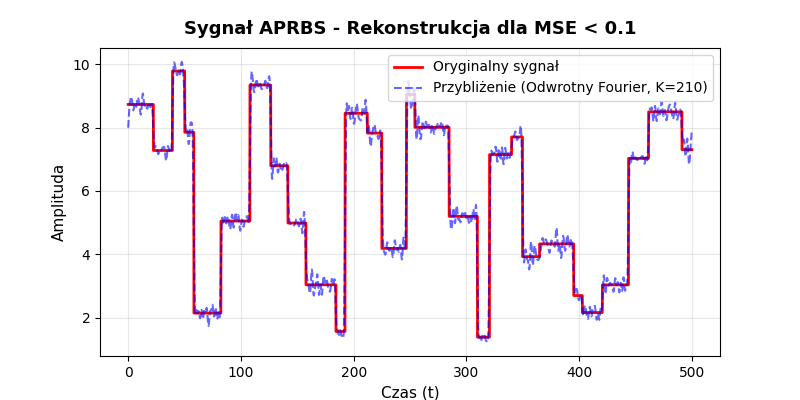


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: MULTISINE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Średniokwadratowy (MSE)
[Konfiguracja] Zadany próg tolerancji,0.1000
[Wynik selekcji] Wymagana liczba składowych (K),13
Energia oryginału (w dziedzinie czasu),159777.0523
Energia po rekonstrukcji (w dziedzinie czasu),159297.2194
Procentowa strata energii,0.3003%
MSE,0.0960
RMSE,0.3098
MAX ERROR,1.9198
Wskaźnik zniekształcenia PRD,5.48%


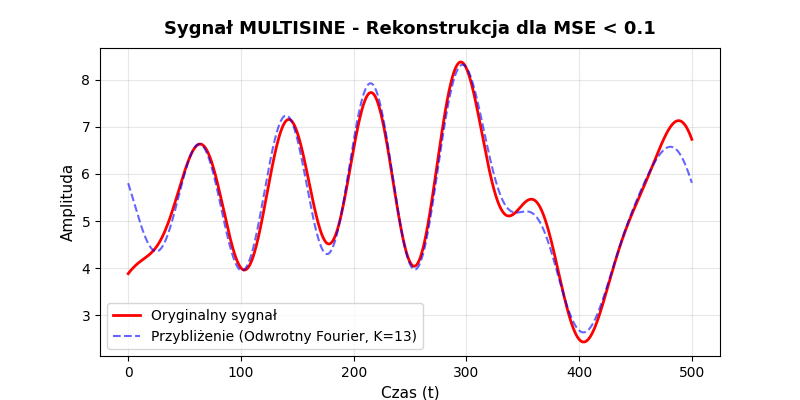


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: NOISE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Średniokwadratowy (MSE)
[Konfiguracja] Zadany próg tolerancji,0.1000
[Wynik selekcji] Wymagana liczba składowych (K),102
Energia oryginału (w dziedzinie czasu),214293.1608
Energia po rekonstrukcji (w dziedzinie czasu),213787.6057
Procentowa strata energii,0.2359%
MSE,0.0999
RMSE,0.3161
MAX ERROR,1.6173
Wskaźnik zniekształcenia PRD,4.83%


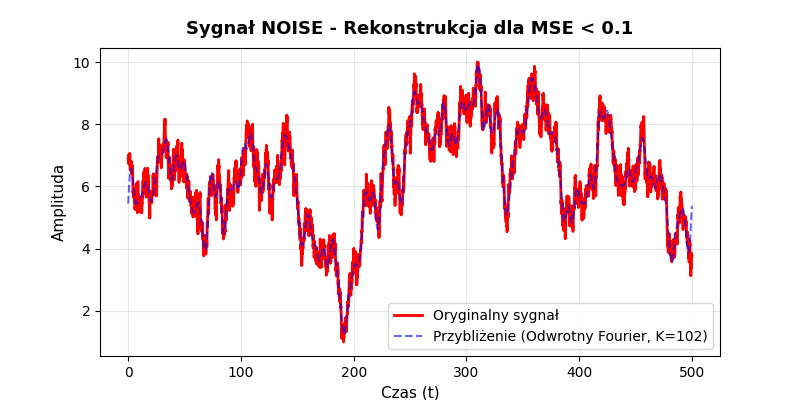


[SUKCES] Wszystkie typy sygnałów zostały pomyślnie przeanalizowane i zaraportowane!


In [22]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 
from Fourier import DiscreteFourier
from FidelityAnalyzer import FidelityAnalyzer
from TableRenderer import ReportTableRenderer 
from SignalMetrics import SignalMetrics

# Inicjalizacja generatora i utworzenie zbioru danych
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
dataset = creator.create_dataset(n_aprbs=1, n_multisine=1, n_noise=1)

# Lista wszystkich rodzajów sygnałów do sekwencyjnej analizy
signal_types = ['aprbs', 'multisine', 'noise']

# Konfiguracja kryterium wierności (Fidelity)
max_allowed_diff = 0.1 
mode = 'mse'  # Opcje: 'mse' lub 'max_error'

# ==================================================================================
# GŁÓWNA PĘTLA PRZETWARZANIA
# ==================================================================================
for signal_type in signal_types:
    print(f"\n[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: {signal_type.upper()}")
    
    # Bezpieczne pobranie pierwszego sygnału z danej kategorii
    signal = dataset[signal_type][0]

    # ------------------------------------------------------------------------------
    # KROK 1: Wyznaczenie pełnego widma autorską metodą Fouriera
    omega_vec, f_omega_vec = DiscreteFourier.transform(signal.t, signal.y)

    # KROK 2: Analiza wierności - dynamiczne wyznaczenie progu K dla błędu < max_allowed_diff
    results = FidelityAnalyzer.analyze_by_error(
        signal.y, f_omega_vec, threshold=max_allowed_diff, mode=mode, use_numpy=False
    )
    
    k_threshold = results['k_threshold']

    # KROK 3: Kompresja i rekonstrukcja sygnału w dziedzinie czasu
    f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=k_threshold)
    y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)
    # ------------------------------------------------------------------------------

    # Ewaluacja metryk jakości rekonstrukcji sygnału
    metrics_results = SignalMetrics.evaluate_reconstruction(signal.y, y_reconstructed)

    # Konstrukcja struktury raportu tabelarycznego
    error_label = "Średniokwadratowy (MSE)" if mode == 'mse' else "Maksymalny (MAX ERROR)"
    headers = ["Parametr / Wskaźnik jakości", "Wartość"]

    # Sekcja A: Konfiguracja testu
    rows = [
        ["[Konfiguracja] Tryb analizy błędu", f"{error_label}"],
        ["[Konfiguracja] Zadany próg tolerancji", f"{max_allowed_diff:.4f}"],
        ["[Wynik selekcji] Wymagana liczba składowych (K)", f"{k_threshold}"],
    ]

    # Sekcja B: Automatyczne formatowanie metryk dynamicznych
    for key, val in metrics_results.items():
        if "strata" in key.lower():
            formatted_val = f"{val:.4f}%"
        elif "prd" in key.lower():
            formatted_val = f"{val:.2f}%"
        else:
            formatted_val = f"{val:.4f}" if isinstance(val, float) else str(val)
            
        rows.append([key, formatted_val])

    # Wyrenderowanie tabeli podsumowującej w notebooku
    ReportTableRenderer.render(
        title=f"Kompletny raport wierności i energii sygnału {signal_type.upper()} (K = {k_threshold})",
        headers=headers,
        rows=rows
    )

    # KROK 7: Wizualizacja rekonstrukcji w osobnym oknie wykresu
    Plotter.plot_fourier_comparison(
        signal.t, 
        signal.y, 
        y_reconstructed, 
        K=k_threshold,
        title=f"Sygnał {signal_type.upper()} - Rekonstrukcja dla {mode.upper()} < {max_allowed_diff}"
    )
    
print("\n[SUKCES] Wszystkie typy sygnałów zostały pomyślnie przeanalizowane i zaraportowane!")

#### ***4.2.4 Kod (Analiza dokładności wg. Max Error)***

**Analiza dokładnośći pod względem Max Error sygnałów APRBS, Multisine i Filtered Noise**

W trakcie wykonywania tego kodu realizowany jest sekwencyjny proces iteracyjnej optymalizacji, kompresji oraz ewaluacji dokładności odtworzenia dla trzech typów sygnałów. Dla każdego z nich wyznaczane jest pełne widmo częstotliwościowe, a następnie zewnętrzny moduł analityczny dynamicznie wyznacza minimalną liczbę składowych $K$ wymaganą do tego, aby błąd bezwzględny rekonstrukcji (w tym przypadku błąd maksymalny) nie przekroczył zadanego progu tolerancji równego $1{,}0$.

Generowanie APRBS        :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/1 [00:00<?, ?it/s]


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: APRBS


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Maksymalny (Max Error)
[Konfiguracja] Zadany próg tolerancji,1.0000
[Wynik selekcji] Wymagana liczba składowych (K),2464
Energia oryginału (w dziedzinie czasu),199496.0184
Energia po rekonstrukcji (w dziedzinie czasu),199470.4277
Procentowa strata energii,0.0128%
MSE,0.0051
RMSE,0.0715
MAX ERROR,0.9991
Wskaźnik zniekształcenia PRD,1.13%


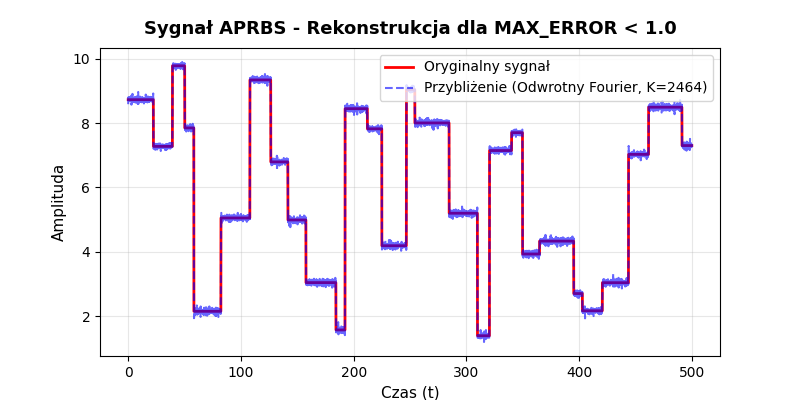


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: MULTISINE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Maksymalny (Max Error)
[Konfiguracja] Zadany próg tolerancji,1.0000
[Wynik selekcji] Wymagana liczba składowych (K),1495
Energia oryginału (w dziedzinie czasu),159777.0523
Energia po rekonstrukcji (w dziedzinie czasu),159774.5075
Procentowa strata energii,0.0016%
MSE,0.0005
RMSE,0.0226
MAX ERROR,0.9998
Wskaźnik zniekształcenia PRD,0.40%


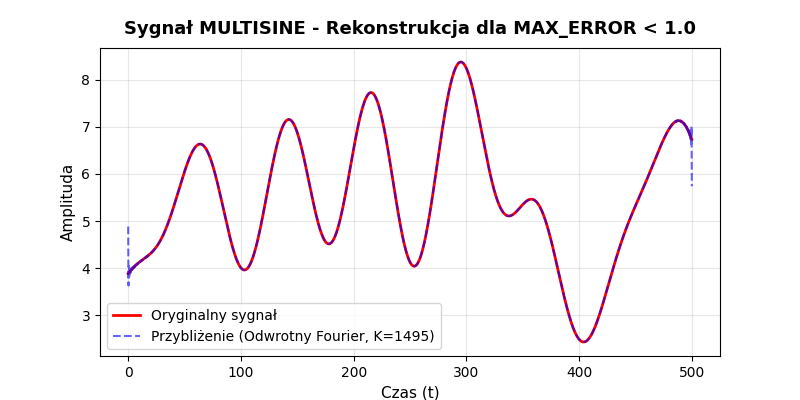


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: NOISE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Maksymalny (Max Error)
[Konfiguracja] Zadany próg tolerancji,1.0000
[Wynik selekcji] Wymagana liczba składowych (K),1390
Energia oryginału (w dziedzinie czasu),214293.1608
Energia po rekonstrukcji (w dziedzinie czasu),214262.2237
Procentowa strata energii,0.0144%
MSE,0.0062
RMSE,0.0786
MAX ERROR,0.9990
Wskaźnik zniekształcenia PRD,1.20%


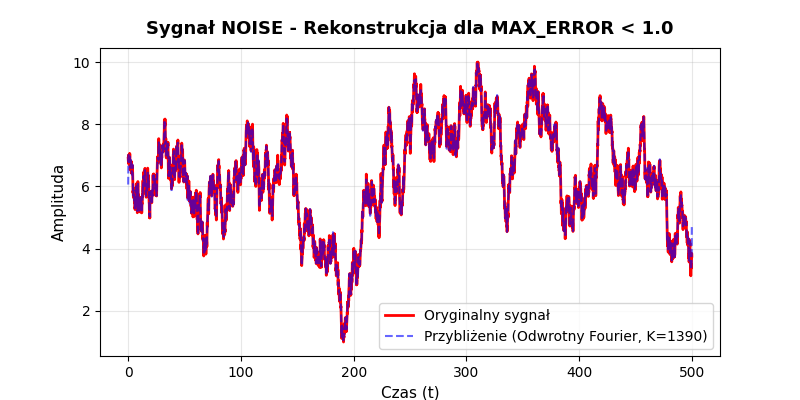


[SUKCES] Wszystkie typy sygnałów zostały pomyślnie przeanalizowane i zaraportowane!


In [23]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 
from Fourier import DiscreteFourier
from FidelityAnalyzer import FidelityAnalyzer
from TableRenderer import ReportTableRenderer 
from SignalMetrics import SignalMetrics

# Inicjalizacja generatora i utworzenie zbioru danych
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
dataset = creator.create_dataset(n_aprbs=1, n_multisine=1, n_noise=1)

# Lista wszystkich rodzajów sygnałów do sekwencyjnej analizy
signal_types = ['aprbs', 'multisine', 'noise']

# Konfiguracja kryterium wierności (Fidelity)
max_allowed_diff = 1.0 
mode = 'max_error'  # Opcje: 'mse' lub 'max_error'

# ==================================================================================
# GŁÓWNA PĘTLA PRZETWARZANIA
# ==================================================================================
for signal_type in signal_types:
    print(f"\n[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: {signal_type.upper()}")
    
    # Bezpieczne pobranie pierwszego sygnału z danej kategorii
    signal = dataset[signal_type][0]

    # ------------------------------------------------------------------------------
    # KROK 1: Wyznaczenie pełnego widma autorską metodą Fouriera
    omega_vec, f_omega_vec = DiscreteFourier.transform(signal.t, signal.y)

    # KROK 2: Analiza wierności - dynamiczne wyznaczenie progu K dla błędu < max_allowed_diff
    results = FidelityAnalyzer.analyze_by_error(
        signal.y, f_omega_vec, threshold=max_allowed_diff, mode=mode, use_numpy=False
    )
    
    k_threshold = results['k_threshold']

    # KROK 3: Kompresja i rekonstrukcja sygnału w dziedzinie czasu
    f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=k_threshold)
    y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)
    # ------------------------------------------------------------------------------

    # Ewaluacja metryk jakości rekonstrukcji sygnału
    metrics_results = SignalMetrics.evaluate_reconstruction(signal.y, y_reconstructed)

    # Konstrukcja struktury raportu tabelarycznego
    error_label = "Średniokwadratowy (MSE)" if mode == 'mse' else "Maksymalny (Max Error)"
    headers = ["Parametr / Wskaźnik jakości", "Wartość"]

    # Sekcja A: Konfiguracja testu
    rows = [
        ["[Konfiguracja] Tryb analizy błędu", f"{error_label}"],
        ["[Konfiguracja] Zadany próg tolerancji", f"{max_allowed_diff:.4f}"],
        ["[Wynik selekcji] Wymagana liczba składowych (K)", f"{k_threshold}"],
    ]

    # Sekcja B: Automatyczne formatowanie metryk dynamicznych
    for key, val in metrics_results.items():
        if "strata" in key.lower():
            formatted_val = f"{val:.4f}%"
        elif "prd" in key.lower():
            formatted_val = f"{val:.2f}%"
        else:
            formatted_val = f"{val:.4f}" if isinstance(val, float) else str(val)
            
        rows.append([key, formatted_val])

    # Wyrenderowanie tabeli podsumowującej w notebooku
    ReportTableRenderer.render(
        title=f"Kompletny raport wierności i energii sygnału {signal_type.upper()} (K = {k_threshold})",
        headers=headers,
        rows=rows
    )

    # Wizualizacja rekonstrukcji w osobnym oknie wykresu
    Plotter.plot_fourier_comparison(
        signal.t, 
        signal.y, 
        y_reconstructed, 
        K=k_threshold,
        title=f"Sygnał {signal_type.upper()} - Rekonstrukcja dla {mode.upper()} < {max_allowed_diff}"
    )
    
print("\n[SUKCES] Wszystkie typy sygnałów zostały pomyślnie przeanalizowane i zaraportowane!")

---

## **5. Testy**


W tej sekcji zajmiemy się sprawdzeniem, jak nasze algorytmy kompresji oparte na transformacji Fouriera radzą sobie w praktyce przy masowym przetwarzaniu danych. Cały proces testowy został zaprojektowany tak, aby czarno na białym pokazać różnice pomiędzy wycinaniem widma za pomocą kryterium energetycznego a kryteriami dokładnościowymi (Fidelity).

Pokrótce omówimy tutaj konfigurację środowiska testowego, parametry przyjętych progów oraz to, jak zoptymalizowaliśmy skrypty pod kątem wydajności. Następnie przeanalizujemy, z jakimi problemami numerycznymi mierzą się algorytmy przy każdym z trzech typów sygnałów: skokowym (APRBS), sinusoidalnym (Multisine) oraz czystym szumie (Noise). Całość podsumujemy zbiorczymi tabelami z wynikami statystycznymi dla całej bazy danych.


### **5.1 Założenia testowe**



Eksperymenty numeryczne mają na celu masową i rygorystyczną ocenę efektywności kompresji spektralnej przy użyciu transformacji Fouriera. Zgodnie z wcześniejszymi założeniami projektowymi, zasadnicza faza testów masowych została przeprowadzona na **zbiorach danych czystych (niezaszumionych)** w celu precyzyjnej izolacji właściwości aproksymacyjnych samych kryteriów selekcji harmonicznych. 

**Główne zadanie skryptu testowego** 

Nadrzędnym celem algorytmu realizowanego w pętli masowej jest sekwencyjne wczytanie każdego sygnału z bazy danych, wyznaczenie jego pełnego widma częstotliwościowego, a następnie automatyczne wyliczenie optymalnego progu odcięcia (parametru $K$) niezależnie dla każdego z trzech kryteriów selekcji. Końcowym etapem jest kompresja widma, rekonstrukcja sygnału w dziedzinie czasu oraz automatyczna agregacja pełnego zestawu metryk jakościowych (MSE, RMSE, Max Error, PRD) w celu wyznaczenia wartości średnich i odchyleń standardowych dla całej populacji testowej.

**Metodologia wykonania i optymalizacja obliczeniowa**

Badania masowe zrealizowano dla bazy danych zawierającej po 1000 niezależnych sygnałów dla każdej z trzech głównych klas (APRBS, Multisine, Noise). **Wszystkie sygnały testowe w bazie zostały wygenerowane w przedziale amplitudy od 1 do 10, co stanowi bezpośredni punkt odniesienia dla interpretacji wartości bezwzględnych błędów rekonstrukcji (MSE, RMSE, Max Error).**

 W strukturze testów przyjęto następujące parametry konfiguracyjne dla poszczególnych strategii odcinania widma:

1. **Kryterium Energetyczne:** Progi zachowania skumulowanej energii widma ustawiono na poziomach: $99.0\%$, $99.9\%$ oraz $99.99\%$.
2. **Kryterium Dokładnościowe (Fidelity MSE):** Dopuszczalne progi błędu średniokwadratowego zdefiniowano jako: $0.01$, $0.1$ oraz $1.0$.
3. **Kryterium Dokładnościowe (Fidelity Max Error):** Maksymalne dopuszczalne odchylenie lokalne zdefiniowano na poziomach: $0.01$, $0.1$ oraz $1.0$.

Ze względu na specyfikę testów masowych (analiza łącznie kilku tysięcy sygnałów o długości 5000 próbek każdy, dla wielu konfiguracji progowych), kluczowym wyzwaniem okazała się złożoność obliczeniowa. Algorytmy zostały zaimplementowane i przetestowane w oparciu o dwa silniki matematyczne:
* **Autorska implementacja Fouriera (`DiscreteFourier`):** Służy jako referencyjny dowód poprawności matematycznej i logicznej całego aparatu kompresji. Została ona uruchomiona i zaprezentowana w ramach jednostkowego, szczegółowego profilowania algorytmów dla pojedynczych reprezentantów klasy sygnałowej (*APRBS*).

* **Silnik obliczeniowy NumPy (`np.fft`):** Ze względu na zoptymalizowane pod kątem sprzętowym funkcjonalności i nieporównywalnie wyższą szybkość wykonywania operacji, **całość zasadniczych testów masowych i agregacji statystyk w pętlach została zrealizowana przy użyciu silnika NumPy**. Pozwoliło to na skrócenie czasu przetwarzania zbiorów danych z wielu godzin do zaledwie kilkunastu sekund, przy zachowaniu tożsamej precyzji numerycznej.



### **5.2. Efektywność kompresji dla sygnałów APRBS:**


Sygnały typu APRBS (*Amplitude Pseudo-Random Binary Sequence*), jako przebiegi o charakterze skokowym, nieliniowym i nieciągłym, stanowią z natury najbardziej wymagający i problematyczny obiekt dla kompresji w dziedzinie częstotliwości. 

**Główne wyzwania:**

* **Nieskończone widmo a problem odcięcia:** Z punktu widzenia analizy spektralnej, idealnie pionowe zbocza sygnału skokowego generują nieskończone, wolno opadające pasmo częstotliwości. Wyzwanie kompresji polega tutaj na znalezieniu kompromisu pomiędzy redukcją danych a zachowaniem geometrii sygnału. 

* **Efekt Gibbsa jako bariera jakościowa:** Główne wyzwanie inżynierskie wiąże się z faktem, że odcięcie wyższych harmonicznych (niezbędnych do idealnej rekonstrukcji ostrych kantów) skutkuje powstawaniem tzw. efektu Gibbsa. Przejawia się on w postaci charakterystycznych oscylacji i "zafalowań" w rejonie występujących skoków amplitudy. Z tego powodu kryteria dokładnościowe (szczególnie maksymalny błąd lokalny) zmuszone są do drastycznego zwiększania liczby zachowywanych składowych ($K$), co bezpośrednio uderza w efektywność samej kompresji.

 
#### *Kod (Autorska implementacja Fourier'a)*


W trakcie wykonywania tego skryptu realizowany jest proces zautomatyzowanego testowania i agregacji danych statystycznych dla sygnałów typu APRBS przy użyciu autorskiego silnika przekształcenia Fouriera.

In [24]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Tester import FidelityTester, EnergyTester, TesterUtils

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
big_dataset = creator.create_dataset(n_aprbs=2, n_multisine=2, n_noise=2)
signal_type = 'aprbs'

save = False # Ustaw na True, jeśli chcesz zapisać wyniki do plików CSV i Markdown
folder = "Custom_FFT" # Nazwa folderu do zapisu wyników dla autorskiego silnika FFT
use_custom_fft = True # Ustaw na False, aby użyć silnika NumPy, True dla autorskiego silnika FFT

# --- INICJALIZACJA TESTERÓW ---
energy_tester = EnergyTester(big_dataset)
fidelity_tester = FidelityTester(big_dataset)

# ==========================================================================
# ODPALENIE DLA SYGNAŁÓW APRBS - na silniku autorskim (use_custom_fft=True)
# ==========================================================================
# Krok 1: Zbieranie surowych danych
raw_energy_aprbs = energy_tester.run(signal_type, use_custom_fft=use_custom_fft)
raw_fidelity_mse_aprbs = fidelity_tester.run(signal_type, mode='mse', use_custom_fft=use_custom_fft)  
raw_fidelity_maxerror_aprbs = fidelity_tester.run(signal_type, mode='max_error', use_custom_fft=use_custom_fft) 

# Zapis danych pełnych (Niezagregowanych)
if save:
    TesterUtils.save_csv(raw_energy_aprbs, f"{folder}\\{signal_type}", f"raw_energy_custom_fft_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_mse_aprbs, f"{folder}\\{signal_type}", f"raw_fidelity_mse_custom_fft_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_maxerror_aprbs, f"{folder}\\{signal_type}", f"raw_fidelity_maxerror_custom_fft_{signal_type}.csv")

# Krok 2: Proces agregacji statystyk w Pandas (zwraca DataFrame)
summary_energy_aprbs = TesterUtils.aggregate(raw_energy_aprbs)
summary_fidelity_mse_aprbs = TesterUtils.aggregate(raw_fidelity_mse_aprbs)
summary_fidelity_maxerror_aprbs = TesterUtils.aggregate(raw_fidelity_maxerror_aprbs)

# Zapis danych zagregowanych
if save:
    TesterUtils.save_csv(summary_energy_aprbs, f"{folder}\\{signal_type}", f"summary_energy_custom_fft_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_mse_aprbs, f"{folder}\\{signal_type}", f"summary_fidelity_mse_custom_fft_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_maxerror_aprbs, f"{folder}\\{signal_type}", f"summary_fidelity_maxerror_custom_fft_{signal_type}.csv")

# Krok 3: Wyświetlenie gotowych tabel HTML
TesterUtils.render(signal_type, summary_energy_aprbs, save_md=save, save_name_suffix=f"summary_energy_custom_fft_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_mse_aprbs, save_md=save, save_name_suffix=f"summary_fidelity_mse_custom_fft_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_maxerror_aprbs, save_md=save, save_name_suffix=f"summary_fidelity_maxerror_custom_fft_{signal_type}", folder=f"{folder}\\{signal_type}")

Generowanie APRBS        :   0%|          | 0/2 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/2 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/2 [00:00<?, ?it/s]

Kryterium Energetyczne: APRBS                                            0%|          | 0/2 [00:00<?, ?it/s]

Kryterium Fidelity: APRBS - Silnik: Autorski - Metryka: MSE                   0%|          | 0/2 [00:00<?, ?it…

Kryterium Fidelity: APRBS - Silnik: Autorski - Metryka: MAX_ERROR             0%|          | 0/2 [00:00<?, ?it…

Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Energetyczne,Prog_Energii_99.0%,2,72.0,51,93,29.70,0.36084,0.5999,3.665,9.991%
Energetyczne,Prog_Energii_99.9%,2,713.0,534,892,253.14,0.03608,0.1897,2.836,3.159%
Energetyczne,Prog_Energii_99.99%,2,2957.0,2715,3199,342.24,0.00361,0.0600,0.654,1.000%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MSE),Tolerancja_0.01,2,1911.5,1723,2100,266.58,0.01000,0.1000,1.54,1.67%
Fidelity (MSE),Tolerancja_0.1,2,254.0,210,298,62.23,0.09965,0.3157,3.28,5.27%
Fidelity (MSE),Tolerancja_1.0,2,27.5,25,30,3.54,0.97472,0.9873,3.81,16.48%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MAX_ERROR),Tolerancja_0.01,2,4895.5,4893,4898,3.54,0.00000693,0.00263,0.00986,0.0440%
Fidelity (MAX_ERROR),Tolerancja_0.1,2,4290.0,4253,4327,52.33,0.00036601,0.01913,0.09957,0.3198%
Fidelity (MAX_ERROR),Tolerancja_1.0,2,2479.5,2464,2495,21.92,0.00604415,0.07751,0.99873,1.2998%


 
#### *Kod (Numpy'owa implementacja Fourier'a)*


W trakcie wykonywania tego skryptu realizowany jest proces zautomatyzowanego testowania i agregacji danych statystycznych dla sygnałów typu APRBS przy użyciu silnika przekształcenia Fouriera z biblioteki Numpy.

In [25]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Tester import FidelityTester, EnergyTester, TesterUtils

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
big_dataset = creator.create_dataset(n_aprbs=100, n_multisine=0, n_noise=0)
signal_type = 'aprbs'

save = False # Ustaw na True, jeśli chcesz zapisać wyniki do plików CSV i Markdown
folder = "Numpy_FFT" # Nazwa folderu do zapisu wyników dla silnika NumPy
use_custom_fft = False # Ustaw na False, aby użyć silnika NumPy, True dla autorskiego silnika FFT

# --- INICJALIZACJA TESTERÓW ---
energy_tester = EnergyTester(big_dataset)
fidelity_tester = FidelityTester(big_dataset)

# =========================================================================
# ODPALENIE DLA SYGNAŁÓW APRBS - na silniku NumPy
# =========================================================================
# Krok 1: Zbieranie surowych danych
raw_energy_aprbs = energy_tester.run(signal_type, use_custom_fft=use_custom_fft)
raw_fidelity_mse_aprbs = fidelity_tester.run(signal_type, mode='mse', use_custom_fft=use_custom_fft)  
raw_fidelity_maxerror_aprbs = fidelity_tester.run(signal_type, mode='max_error', use_custom_fft=use_custom_fft) 

# Zapis danych pełnych (Niezagregowanych)
if save:
    TesterUtils.save_csv(raw_energy_aprbs, folder=f"{folder}\\{signal_type}", filename=f"raw_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_mse_aprbs, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_maxerror_aprbs, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 2: Proces agregacji statystyk w Pandas (zwraca DataFrame)
summary_energy_aprbs = TesterUtils.aggregate(raw_energy_aprbs)
summary_fidelity_mse_aprbs = TesterUtils.aggregate(raw_fidelity_mse_aprbs)
summary_fidelity_maxerror_aprbs = TesterUtils.aggregate(raw_fidelity_maxerror_aprbs)

# Zapis danych zagregowanych
if save:
    TesterUtils.save_csv(summary_energy_aprbs, folder=f"{folder}\\{signal_type}", filename=f"summary_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_mse_aprbs, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_maxerror_aprbs, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 3: Wyświetlenie gotowych tabel HTML
TesterUtils.render(signal_type, summary_energy_aprbs, save_md=save, save_name_suffix=f"summary_energy_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_mse_aprbs, save_md=save, save_name_suffix=f"summary_fidelity_mse_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_maxerror_aprbs, save_md=save, save_name_suffix=f"summary_fidelity_maxerror_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")

Generowanie APRBS        :   0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Energetyczne: APRBS                                            0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Fidelity: APRBS - Silnik: NumPy - Metryka: MSE                      0%|          | 0/100 [00:00<?, ?…

Kryterium Fidelity: APRBS - Silnik: NumPy - Metryka: MAX_ERROR                0%|          | 0/100 [00:00<?, ?…

Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Energetyczne,Prog_Energii_99.0%,100,81.1,29,218,31.49,0.36587,0.6030,3.921,9.938%
Energetyczne,Prog_Energii_99.9%,100,765.9,285,1685,257.95,0.03702,0.1918,2.946,3.160%
Energetyczne,Prog_Energii_99.99%,100,2975.3,1968,3725,320.10,0.00370,0.0607,0.645,1.000%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MSE),Tolerancja_0.01,100,1986.6,976,2803,369.37,0.00999,0.1000,1.50,1.66%
Fidelity (MSE),Tolerancja_0.1,100,290.5,102,586,97.03,0.09973,0.3158,3.51,5.24%
Fidelity (MSE),Tolerancja_1.0,100,29.9,11,67,9.67,0.97716,0.9885,4.23,16.41%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MAX_ERROR),Tolerancja_0.01,100,4897.2,4839,4927,17.48,0.00000708,0.00265,0.00984,0.0440%
Fidelity (MAX_ERROR),Tolerancja_0.1,100,4239.1,4005,4423,83.53,0.00045075,0.02109,0.09953,0.3497%
Fidelity (MAX_ERROR),Tolerancja_1.0,100,2487.4,1980,2753,146.20,0.00649071,0.07979,0.99913,1.3221%



### **5.3. Efektywność kompresji dla sygnałów Multisine:**

Wieloczęstotliwościowe sygnały sinusoidalne reprezentują zupełnie odmienny charakter spektralny, będący idealnym środowiskiem dla ortogonalnej kompresji Fouriera. 

**Główne wyzwania:**

* **Problem rzadkości widma:** Podstawowym zagadnieniem badawczym w przypadku sygnałów *multisine* jest sprawdzenie, czy algorytmy selekcji potrafią bezbłędnie zidentyfikować deterministyczną strukturę harmonicznych. Ponieważ sygnał ten składa się fizycznie ze skończonej liczby czystych sinusoid, jego energia skupiona jest wyłącznie w konkretnych, odizolowanych prążkach częstotliwościowych.


#### *Kod (Numpy'owa implementacja Fourier'a)*

W trakcie wykonywania tego skryptu realizowany jest proces zautomatyzowanego testowania i agregacji danych statystycznych dla sygnałów typu Multisine przy użyciu silnika przekształcenia Fouriera z biblioteki Numpy.

In [26]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Tester import FidelityTester, EnergyTester, TesterUtils

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
big_dataset = creator.create_dataset(n_aprbs=0, n_multisine=100, n_noise=0)
signal_type = 'multisine'

save = False # Ustaw na True, jeśli chcesz zapisać wyniki do plików CSV i Markdown
folder = "Numpy_FFT" # Nazwa folderu do zapisu wyników dla silnika NumPy
use_custom_fft = False # Ustaw na False, aby użyć silnika NumPy, True dla autorskiego silnika FFT

# --- INICJALIZACJA TESTERÓW ---
energy_tester = EnergyTester(big_dataset)
fidelity_tester = FidelityTester(big_dataset)

# =========================================================================
# ODPALENIE DLA SYGNAŁÓW MULTISINE - na silniku NumPy
# =========================================================================
# Krok 1: Zbieranie surowych danych
raw_energy_multisine = energy_tester.run(signal_type, use_custom_fft=use_custom_fft)
raw_fidelity_mse_multisine = fidelity_tester.run(signal_type, mode='mse', use_custom_fft=use_custom_fft)  
raw_fidelity_maxerror_multisine = fidelity_tester.run(signal_type, mode='max_error', use_custom_fft=use_custom_fft) 

# Zapis danych pełnych (Niezagregowanych)
if save:
    TesterUtils.save_csv(raw_energy_multisine, folder=f"{folder}\\{signal_type}", filename=f"raw_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_mse_multisine, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_maxerror_multisine, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 2: Proces agregacji statystyk w Pandas (zwraca DataFrame)
summary_energy_multisine = TesterUtils.aggregate(raw_energy_multisine)
summary_fidelity_mse_multisine = TesterUtils.aggregate(raw_fidelity_mse_multisine)
summary_fidelity_maxerror_multisine = TesterUtils.aggregate(raw_fidelity_maxerror_multisine)

# Zapis danych zagregowanych
if save:
    TesterUtils.save_csv(summary_energy_multisine, folder=f"{folder}\\{signal_type}", filename=f"summary_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_mse_multisine, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_maxerror_multisine, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 3: Wyświetlenie gotowych tabel HTML
TesterUtils.render(signal_type, summary_energy_multisine, save_md=save, save_name_suffix=f"summary_energy_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_mse_multisine, save_md=save, save_name_suffix=f"summary_fidelity_mse_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_maxerror_multisine, save_md=save, save_name_suffix=f"summary_fidelity_maxerror_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")

Generowanie MULTISINE    :   0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Energetyczne: MULTISINE                                        0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Fidelity: MULTISINE - Silnik: NumPy - Metryka: MSE                  0%|          | 0/100 [00:00<?, ?…

Kryterium Fidelity: MULTISINE - Silnik: NumPy - Metryka: MAX_ERROR            0%|          | 0/100 [00:00<?, ?…

Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Energetyczne,Prog_Energii_99.0%,100,5.4,1,14,2.43,0.23704,0.4806,1.244,8.589%
Energetyczne,Prog_Energii_99.9%,100,14.6,5,64,8.33,0.02386,0.1517,0.870,2.710%
Energetyczne,Prog_Energii_99.99%,100,80.8,7,614,97.24,0.00281,0.0524,0.688,0.938%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MSE),Tolerancja_0.01,100,29.5,6,206,29.53,0.00874,0.0928,0.778,1.66%
Fidelity (MSE),Tolerancja_0.1,100,9.0,2,24,3.62,0.08027,0.2815,1.001,5.05%
Fidelity (MSE),Tolerancja_1.0,100,1.7,1,6,1.15,0.73005,0.8452,1.886,15.16%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MAX_ERROR),Tolerancja_0.01,100,4653.1,76,4978,890.88,0.00000124,0.00104,0.00994,0.0186%
Fidelity (MAX_ERROR),Tolerancja_0.1,100,3514.3,12,4778,1352.74,0.00003994,0.00466,0.09915,0.0840%
Fidelity (MAX_ERROR),Tolerancja_1.0,100,206.2,1,2779,523.85,0.09813997,0.26505,0.93191,4.7832%


### **5.4. Efektywność kompresji dla sygnałów Filtered Noise:**


Klasa sygnałów stochastycznych (szumowych) definiuje skrajny przypadek problemu kompresji spektralnej, w którym deterministyczne podejście bazujące na dominujących harmonicznych napotyka fundamentalne ograniczenia. 

**Główne wyzwania:**

* **Problem gęstej dystrybucji energii:** Sygnał szumowy charakteryzuje się widmem ciągłym, gęstym i równomiernie rozłożonym w całym pasmie analitycznym. W przeciwieństwie do poprzednich klas, nie występują tutaj żadne dominanty częstotliwościowe – każda składowa niesie zbliżony ładunek informacyjny i energetyczny.

* **Zjawisko filtracji zamiast kompresji:** Głównym problemem podlegającym badaniu jest zachowanie algorytmów w sytuacji, gdy redukcja danych (zmniejszanie parametru $K$) nie wynika z eliminacji redundancji, lecz działa jak klasyczny filtr dolnoprzepustowy. Usunięcie jakiejkolwiek części widma wiąże się w tym przypadku z bezpośrednim i nieodwracalnym wygładzaniem trajektorii czasowej. Wyzwaniem testowym jest tu wykazanie, jak wysokie wymagania stawiane są algorytmom kompresji Fouriera w obliczu procesów czysto losowych, gdzie zachowanie wysokiej wierności zmusza system do przetwarzania niemal pełnego widma częstotliwościowego.


#### *Kod (Numpy'owa implementacja Fourier'a)*

W trakcie wykonywania tego skryptu realizowany jest proces zautomatyzowanego testowania i agregacji danych statystycznych dla sygnałów typu Filtered Noise przy użyciu silnika przekształcenia Fouriera z biblioteki Numpy.

In [27]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Tester import FidelityTester, EnergyTester, TesterUtils

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
big_dataset = creator.create_dataset(n_aprbs=0, n_multisine=0, n_noise=100)
signal_type = 'noise'

save = False # Ustaw na True, jeśli chcesz zapisać wyniki do plików CSV i Markdown
folder = "Numpy_FFT" # Nazwa folderu do zapisu wyników dla silnika NumPy
use_custom_fft = False # Ustaw na False, aby użyć silnika NumPy, True dla autorskiego silnika FFT

# --- INICJALIZACJA TESTERÓW ---
energy_tester = EnergyTester(big_dataset)
fidelity_tester = FidelityTester(big_dataset)

# =========================================================================
# ODPALENIE DLA SYGNAŁÓW NOISE - na silniku NumPy
# =========================================================================
# Krok 1: Zbieranie surowych danych
raw_energy_noise = energy_tester.run(signal_type, use_custom_fft=use_custom_fft)
raw_fidelity_mse_noise = fidelity_tester.run(signal_type, mode='mse', use_custom_fft=use_custom_fft)  
raw_fidelity_maxerror_noise = fidelity_tester.run(signal_type, mode='max_error', use_custom_fft=use_custom_fft) 

# Zapis danych pełnych (Niezagregowanych)
if save:
    TesterUtils.save_csv(raw_energy_noise, folder=f"{folder}\\{signal_type}", filename=f"raw_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_mse_noise, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_maxerror_noise, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 2: Proces agregacji statystyk w Pandas (zwraca DataFrame)
summary_energy_noise = TesterUtils.aggregate(raw_energy_noise)
summary_fidelity_mse_noise = TesterUtils.aggregate(raw_fidelity_mse_noise)
summary_fidelity_maxerror_noise = TesterUtils.aggregate(raw_fidelity_maxerror_noise)

# Zapis danych zagregowanych
if save:
    TesterUtils.save_csv(summary_energy_noise, folder=f"{folder}\\{signal_type}", filename=f"summary_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_mse_noise, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_maxerror_noise, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 3: Wyświetlenie gotowych tabel HTML
TesterUtils.render(signal_type, summary_energy_noise, save_md=save, save_name_suffix=f"summary_energy_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_mse_noise, save_md=save, save_name_suffix=f"summary_fidelity_mse_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_maxerror_noise, save_md=save, save_name_suffix=f"summary_fidelity_maxerror_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")

Generowanie NOISE        :   0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Energetyczne: NOISE                                            0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Fidelity: NOISE - Silnik: NumPy - Metryka: MSE                      0%|          | 0/100 [00:00<?, ?…

Kryterium Fidelity: NOISE - Silnik: NumPy - Metryka: MAX_ERROR                0%|          | 0/100 [00:00<?, ?…

Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Energetyczne,Prog_Energii_99.0%,100,32.0,12,85,12.58,0.31907,0.5633,2.041,9.824%
Energetyczne,Prog_Energii_99.9%,100,315.8,109,734,118.53,0.03298,0.1811,0.959,3.157%
Energetyczne,Prog_Energii_99.99%,100,2048.0,1013,2994,412.72,0.00331,0.0573,0.349,1.000%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MSE),Tolerancja_0.01,100,950.8,388,1661,300.58,0.00999,0.1000,0.652,1.75%
Fidelity (MSE),Tolerancja_0.1,100,103.8,38,216,38.69,0.09940,0.3153,1.339,5.53%
Fidelity (MSE),Tolerancja_1.0,100,9.6,3,19,3.56,0.93844,0.9684,3.176,16.99%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MAX_ERROR),Tolerancja_0.01,100,4827.8,4719,4892,35.44,0.00000711,0.00266,0.00989,0.0467%
Fidelity (MAX_ERROR),Tolerancja_0.1,100,3534.2,2681,4542,289.44,0.00062316,0.02472,0.09961,0.4327%
Fidelity (MAX_ERROR),Tolerancja_1.0,100,409.4,50,3121,546.76,0.05493389,0.22135,0.99195,3.8753%


### **5.5. Wyniki**

#### ***Analiza sygnałów ARPBS***

Poniżej przedstawiono szczegółową interpretację wyników uzyskanych podczas masowych testów kompresji (1000 sygnałów) dla przebiegów skokowych typu APRBS.

##### Kryterium Energetyczne - Zbiorczy raport dla sygnałów: APRBS

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Próg Energii 99.0%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>80.2</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>21</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>218</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>29.83</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.36876</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.6052</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.873</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>9.939%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Próg Energii 99.9%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>758.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>204</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1685</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>255.02</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.03730</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.1925</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2.924</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.160%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Próg Energii 99.99%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>2968.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1631</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3746</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>329.11</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00373</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0609</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.654</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.000%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity Max Error) - Zbiorczy raport dla sygnałów: APRBS

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>4899.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4815</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4943</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>20.65</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00000706</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00265</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00985</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0438%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>4235.8</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3839</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4476</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>84.88</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00045912</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.02126</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.09955</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.3513%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>2484.6</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1705</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2856</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>167.22</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00653708</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.07996</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.99896</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.3205%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity MSE) - Zbiorczy raport dla sygnałów: APRBS

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>1983.8</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>777</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2916</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>379.94</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00999</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.49</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.65%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>289.6</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>78</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>664</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>100.28</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.09976</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.3158</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.49</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>5.22%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>30.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>10</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>76</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>10.14</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.97518</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.9875</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4.17</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>16.33%</td>
    </tr>
  </tbody>
</table>

##### Podsumowanie i rekomendacja dla APRBS



Przeprowadzone testy masowe jednoznacznie pokazują, że **sygnał o charakterze prostokątnym (skokowym) z natury bardzo słabo nadaje się do efektywnej kompresji przy użyciu bazy Fouriera**. Głównym trendem widocznym we wszystkich próbach jest bezpośredni konflikt pomiędzy redukcją danych a wiernością odwzorowania ostrych krawędzi sygnału. 

Kryterium błędu maksymalnego (`MAX_ERROR`) kompletnie kapituluje w tym środowisku, blokując kompresję (średnie $K$ w okolicach 2484–4899) przez swoją nadwrażliwość na oscylacje Gibbsa powstające przy pionowych zboczach. Z kolei **kryterium Energetyczne oraz Fidelity (MSE) można uznać za narzędzia równorzędne**, a ich realna użyteczność zależy wyłącznie od świadomie przyjętego progu. Jeśli inżynier zgodzi się na pewne zniekształcenia fali, oba te podejścia pozwalają na uzyskanie bardzo dobrego i zbliżonego stopnia kompresji. Na przykład dla progu energii $99.0\%$ otrzymujemy świetną redukcję danych do średniego $K \approx 80$, przy zniekształceniach $PRD \approx 9.94\%$. Zaostrzenie kryterium do $99.9\%$ drastycznie poprawia jakość ($PRD \approx 3.16\%$), ale wymaga już zachowania $K \approx 758$ składowych. Podobną elastyczność oferuje kryterium błędu średniokwadratowego, gdzie dla tolerancji $MSE = 0.1$ algorytm schodzi do $K \approx 290$ (przy $PRD \approx 5.22\%$). 

Ostatecznie wybór między nimi sprowadza się do tego, czy w danym projekcie łatwiej i wygodniej jest operować procentem zachowanej energii całego widma, czy dopuszczalną wartością błędu średniokwadratowego w dziedzinie czasu.

#### ***Analiza sygnałów Multisine***

##### Kryterium Energetyczne - Zbiorczy raport dla sygnałów: MULTISINE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Próg Energii 99.0%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>5.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>16</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2.33</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.22996</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.4734</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.241</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>8.460%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Próg Energii 99.9%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>15.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>115</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>10.14</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.02320</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.1490</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.855</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2.662%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Próg Energii 99.99%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>83.8</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>7</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1087</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>115.26</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00284</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0528</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.688</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.944%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity Max Error) - Zbiorczy raport dla sygnałów: MULTISINE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>4724.9</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>76</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4984</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>635.54</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00000123</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00102</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00994</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0183%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>3424.4</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>7</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4832</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1436.08</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00003306</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00438</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.09949</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0785%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>242.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3319</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>586.59</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.10533416</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.27477</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.92909</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4.9480%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity MSE) - Zbiorczy raport dla sygnałów: MULTISINE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>30.7</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>358</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>34.86</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00871</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0927</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.774</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.66%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>9.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>39</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.65</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.07980</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.2806</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.999</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>5.04%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>1.8</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>8</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.13</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.71973</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.8389</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.916</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>15.04%</td>
    </tr>
  </tbody>
</table>

##### Podsumowanie i rekomendacja dla Multisine


Testy masowe jednoznacznie potwierdzają, że **sygnały wieloczęstotliwościowe (Multisine) są świetnym obiektem do kompresji metodą Fouriera**, ale ich rzeczywiste parametry generacji ujawniają fundamentalne ograniczenia dyskretnej transformaty. Sygnały te składają się z losowej liczby komponentów sinusoidalnych ($n_f \in [5; 15]$) o losowych częstotliwościach.

Głównym trendem i wnioskiem inżynierskim jest to, że **kryterium Energetyczne oraz Fidelity (MSE) są narzędziami w pełni równorzędnymi**, dającymi zbliżoną, bardzo wysoką wydajność. Wybór między nimi zależy tylko od preferencji (sterowanie procentem energii widma, gdzie próg $99.9\%$ daje $K \approx 15$, czy wartością błędu w dziedzinie czasu, gdzie $MSE = 0.01$ daje $K \approx 31$).

Kluczowym zjawiskiem zaobserwowanym w badaniach jest zachowanie algorytmów przy bardzo rygorystycznych progach (np. energia $99.99\%$ lub `MAX_ERROR` $\le 0.1$). Ponieważ częstotliwości sygnału są losowane w sposób ciągły, **nie trafiają one idealnie w sztywną, dyskretną siatkę częstotliwościową transformaty Fouriera. Powoduje to tzw. wyciek widma (spectral leakage)** – energia pojedynczej sinusoidy rozlewa się na sąsiednie prążki. Z tego powodu:
1. Przy skrajnie wysokich wymaganiach energetycznych algorytm zmuszony jest dobierać dodatkowe, sztuczne składowe bocznego tła (stąd wzrost średniego $K$ do $83.8$, mimo maksymalnie $15$ fizycznych sinusoid).
2. Wyciek widma generuje niedopasowanie okresowości na brzegach okna analizy, co wywołuje silne oscylacje na początkach i końcach zrekonstruowanego przebiegu. To właśnie te zniekształcenia brzegowe generują wysoki błąd lokalny i kompletnie dyskwalifikują kryterium **MAX_ERROR** ($K > 3400$ dla tolerancji $0.1$).

**Rekomendacja projektowa:** Aby zniwelować ten problem i pozwolić algorytmowi na dokładniejsze "wstrzelenie się" w rzeczywiste częstotliwości generatora, konieczne byłoby zagęszczenie siatki spektralnej, co w praktyce wymagałoby zwiększenia częstotliwości próbkowania.

#### ***Analiza sygnałów Filtered Noise***

##### Kryterium Energetyczne - Zbiorczy raport dla sygnałów: NOISE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Próg Energii 99.0%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>31.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>7</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>88</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>13.20</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.32111</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.5649</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2.055</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>9.824%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Próg Energii 99.9%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>310.4</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>49</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>824</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>126.85</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.03319</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.1816</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.980</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.157%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Próg Energii 99.99%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>2015.2</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>589</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3121</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>451.14</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00333</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0575</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.374</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.000%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity Max Error) - Zbiorczy raport dla sygnałów: NOISE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>4826.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4627</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4913</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>39.68</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00000700</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00264</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00989</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0462%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>3540.3</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2303</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4542</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>283.15</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00060858</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.02438</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.09962</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.4267%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>444.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>29</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3121</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>514.75</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.04999844</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.20870</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.99308</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.6533%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity MSE) - Zbiorczy raport dla sygnałów: NOISE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>934.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>250</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1891</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>313.69</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00999</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.681</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.75%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>101.9</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>22</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>242</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>40.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.09930</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.3151</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.355</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>5.52%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja 1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>9.3</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>24</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.53</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.93660</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.9673</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.179</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>16.93%</td>
    </tr>
  </tbody>
</table>

##### Podsumowanie i rekomendacja dla Filtered Noise


Masowe testy dla sygnałów zniekształconych szumem (Filtered Noise) reprezentują najtrudniejszy przypadek testowy. Ponieważ szum z natury charakteryzuje się ciągłym, gęstym widmem częstotliwościowym (brak wyraźnych, pojedynczych prążków), algorytmy kompresji oparte na bazie Fouriera napotykają tu na największy opór matematyczny.

Głównym trendem dla tej klasy sygnałów jest ponowna **pełna równorzędność kryterium Energetycznego oraz Fidelity (MSE)**. Oba podejścia bardzo ładnie i przewidywalnie skalują się w zależności od potrzeb użytkownika. Wybór między nimi to ponownie kwestia inżynierskiej wygody:
1. W **kryterium Energetycznym** płynnie sterujemy zachowaniem mocy widma – od silnej kompresji przy progu $99.0\%$ ($K \approx 31.5$, $PRD \approx 9.82\%$) do wysokiej dokładności przy progu $99.99\%$, gdzie jednak algorytm musi zachować aż $K \approx 2015$ składowych, ale uzyskuje  $PRD \approx 1.00\%$.
2. W **kryterium Fidelity (MSE)** uzyskujemy analogiczny, stabilny rozrzut – od ultra-kompresji dla tolerancji $1.0$ ($K \approx 9.3$, $PRD \approx 16.93\%$) do precyzyjnego odwzorowania dla tolerancji $0.01$ ($K \approx 934.5$, $PRD \approx 1.75\%$).

Kryterium błędu maksymalnego (**MAX_ERROR**) po raz kolejny okazuje się **najmniej efektywne i kompletnie kapituluje przy rygorystycznych progach** ($0.01$ oraz $0.1$), blokując kompresję na poziomie średniego $K$ rzędu $3540 - 4826$. Wynika to bezpośrednio z faktu, że losowy charakter szumu generuje ciągłe, nieprzewidywalne fluktuacje amplitudy na przestrzeni całego okna czasowego, a w szczególności na jego brzegach (początek i koniec przebiegu), gdzie transformata Fouriera cierpi na brak okresowości sygnału. Próba zredukowania błędu maksymalnego w tych krytycznych, pojedynczych punktach zmusza algorytm do zapamiętywania niemal całego pasma częstotliwościowego, co całkowicie niweczy sens stosowania kompresji spektralnej dla wyśrubowanych tolerancji lokalnych.

---

## **6. Kompresja Audio**


Kompresja sygnałów dźwiękowych przy użyciu Dyskretnej Transformaty Fouriera opiera się na zjawisku tzw. rzadkości widmowej oraz psychoakustycznych właściwościach ludzkiego słuchu. Sygnał audio zapisany w dziedzinie czasu wydaje się skomplikowany i trudny do uproszczenia bez widocznej utraty jakości. Sytuacja zmienia się po przejściu do domeny częstotliwości.

Większość naturalnych dźwięków, takich jak mowa czy muzyka, skupia swoją główną energię wokół ograniczonej liczby dominujących częstotliwości (tonów podstawowych i ich harmonicznych). Pozostała część widma zawiera informacje o niskiej amplitudzie, szum tła lub częstotliwości mało zauważalne dla ludzkiego ucha. Transformata Fouriera pozwala na precyzyjną identyfikację tych komponentów. Kompresja stratna polega na wyzerowaniu najsłabszych prążków widma, które nie przekraczają zadanego progu energetycznego lub błędu wierności. Przechowywanie tak zredukowanego, "rzadkiego" wektora współczynników wymaga znacznie mniejszej ilości danych, a rekonstrukcja sygnału za pomocą transformaty odwrotnej pozwala odtworzyć brzmienie bardzo bliskie oryginałowi.

### **6.1 Format .wav** 

W badaniach laboratoryjnych oraz profesjonalnej obróbce dźwięku podstawowym standardem zapisu danych jest format WAV (Waveform Audio File Format), opracowany przez firmy Microsoft i IBM. Format ten bazuje na strukturze kontenera RIFF i przechowuje strumień audio najczęściej w postaci nieskompresowanej, kodowanej za pomocą modulacji kodowo-impulsowej (PCM – Pulse-Code Modulation).

Wykorzystanie plików .wav w tym projekcie jest kluczowe z kilku powodów:
- **Brak wstępnej kompresji**: W przeciwieństwie do plików MP3 czy AAC, czysty plik WAV PCM nie zawiera śladów wcześniejszej manipulacji widmowej ani stratnej kompresji psychoakustycznej.
- **Bezpośrednia reprezentacja numeryczna**: Każda próbka w pliku WAV odpowiada rzeczywistej amplitudzie fali dźwiękowej w danym ułamku sekundy (np. zapisana jako 16-bitowa liczba całkowita). Taka struktura pozwala na natychmiastowe wczytanie danych do tablicy NumPy w postaci wektora liczb zmiennopozycyjnych, bez konieczności skomplikowanego dekodowania.
- **Stała częstotliwość próbkowania**: Standardowe pliki WAV posiadają sztywno zdefiniowane parametry, takie jak stałe próbkowanie (np. $44.1\text{ kHz}$) i stałą szerokość bitową. Ułatwia to precyzyjne wyznaczenie kroku czasu $dt$ oraz poprawne wyskalowanie osi częstotliwości w hercach podczas wykonywania transformaty Fouriera.

#### **6.1.1 Przykład kompresji pliku .wav**

Skrypt realizuje kompletny potok przetwarzania sygnału audio – od wczytania surowego pliku, przez jego analizę częstotliwościową i kompresję, aż po zapis wyniku i ewaluację jakości odsłuchu oraz rozmiaru pliku. Proces ten przebiega w pięciu głównych krokach:
- Przygotowanie danych wejściowych: Skrypt wczytuje plik .wav z nagraniem gitary. Jeśli dźwięk jest stereofoniczny, konwertuje go do formatu monofonicznego poprzez uśrednienie kanałów
- Transformata Fouriera: Za pomocą zoptymalizowanej funkcji `np.fft.rfft` sygnał jest transformowany do domeny częstotliwości. Obliczany jest amplituda uzyskanych liczb zespolonych, co pozwala określić strukturę harmoniczną dźwięku.
- Wizualizacja: Generowany jest wykres widma amplitudowego w skali logarytmicznej, obrazujący rozkład energii sygnału
- Kompresja progowa: Zdefiniowano współczynnik kompresji `compression_ratio = 0.1`, co oznacza chęć zachowania jedynie $10\%$ najsilniejszych składowych. Za pomocą funkcji `np.percentile` wyznaczany jest próg amplitudy – wszystkie składowe widma o wartości poniżej tego progu są bezpowrotnie zerowane.
- Rekonstrukcja, zapis i analiza: Zmodyfikowane widmo jest transformowane z powrotem do domeny czasu za pomocą `np.fft.irfft`, konwertowane na format 16-bitowy (int16) i zapisywane jako nowy plik.

Wykres generowany przedstawia widmo amplitudowe sygnału audio w funkcji indeksów częstotliwości. Pozwala zobaczyć wszystkie składowe dźwięku kompresowanego.

C:\Users\grzes\AppData\Local\Temp\ipykernel_3292\865526969.py:14: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, data = wav.read(source_path)
C:\Users\grzes\AppData\Local\Temp\ipykernel_3292\865526969.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


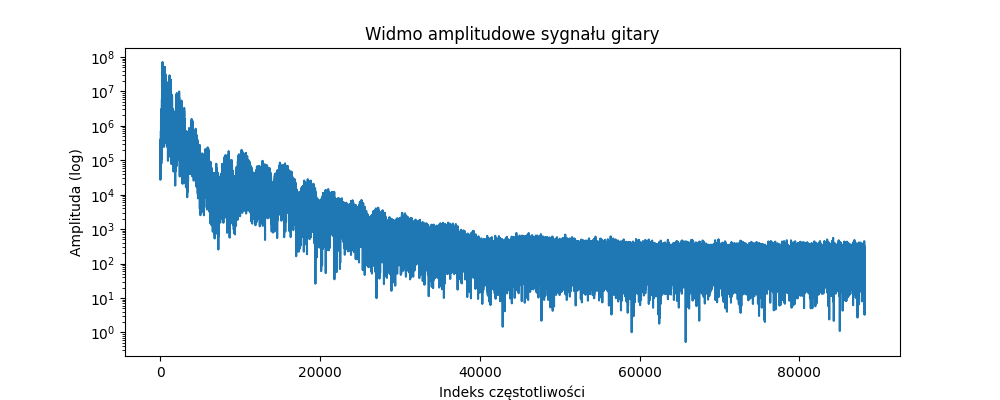

Plik zapisano jako: data/compressed/wynik_cr_0.1_d_07_06_2026_22_46.wav
--- ANALIZA ROZMIARU PLIKÓW ---
Rozmiar oryginału:   690.88 KB
Rozmiar po kompresji: 344.57 KB
Redukcja miejsca:     50.13%
Oryginalny sygnał:


Skompresowany sygnał (po FFT) - compression ratio: 0.1:


In [28]:
import scipy.io.wavfile as wav
import os
import datetime
from IPython.display import Audio, display
import numpy as np
import matplotlib.pyplot as plt

# 1. Ścieżki do katalogów
input_dir = 'data/source'
output_dir = 'data/compressed'

# 2: Ładowanie pliku
source_path = f'{input_dir}/gitara_strun_ma_wiele.wav'
rate, data = wav.read(source_path)

if len(data.shape) > 1:
    data = data.mean(axis=1)
data = data.astype(float)

# 3: Analiza przed kompresją (wizualizacja)
coeffs = np.fft.rfft(data)
amplitudes = np.abs(coeffs)

plt.figure(figsize=(10, 4))
plt.semilogy(amplitudes) # Skala logarytmiczna lepiej pokazuje rozkład energii
plt.title("Widmo amplitudowe sygnału gitary")
plt.xlabel("Indeks częstotliwości")
plt.ylabel("Amplituda (log)")
plt.show()

# 4: Kompresja i zapis
compression_ratio = 0.1  # 10%
threshold = np.percentile(amplitudes, (1 - compression_ratio) * 100)

coeffs_compressed = coeffs.copy()
coeffs_compressed[amplitudes < threshold] = 0

compressed_data = np.int16(np.fft.irfft(coeffs_compressed))

# Zapis
os.makedirs(output_dir, exist_ok=True) # exist_ok=True zastępuje if not os.path.exists

date_str = datetime.datetime.now().strftime('%d_%m_%Y_%H_%M')
compressed_path = f"{output_dir}/wynik_cr_{compression_ratio}_d_{date_str}.wav"

wav.write(compressed_path, rate, compressed_data)
print(f"Plik zapisano jako: {compressed_path}")

def get_file_size_kb(path):
    # Pobiera rozmiar w bajtach i dzieli przez 1024, aby dostać KB
    return os.path.getsize(path) / 1024

# Sprawdzenie rozmiarów
size_orig = get_file_size_kb(source_path)
size_comp = get_file_size_kb(compressed_path)
ratio = (1 - (size_comp / size_orig)) * 100

print(f"--- ANALIZA ROZMIARU PLIKÓW ---")
print(f"Rozmiar oryginału:   {size_orig:.2f} KB")
print(f"Rozmiar po kompresji: {size_comp:.2f} KB")
print(f"Redukcja miejsca:     {ratio:.2f}%")

# 5: Odtwarzanie w notebooku
print("Oryginalny sygnał:")
display(Audio(data, rate=rate))

print(f"Skompresowany sygnał (po FFT) - compression ratio: {compression_ratio}:")
display(Audio(compressed_data, rate=rate))

### **6.2 Własny koder audio**

Aby realnie i rzetelnie zbadać efektywność kompresji widmowej oraz jej bezpośredni wpływ na oszczędność pamięci masowej, stworzyliśmy autorski algorytm kodera i dekodera oparty na dedykowanym formacie binarnym .kmp.
Głównym zadaniem autorskiego kodera jest całkowite odrzucenie zerowych prążków widma i strumieniowy zapis do pliku wyłącznie tych składowych częstotliwościowych, które faktycznie przetrwały prób energetyczny, wraz z informacją o ich indeksach.


**Koder (WAV -> KMP)**

Na początku konwertujemy standardowy dźwięk 16-bitowy do zakresu zmiennopozycyjnego [-1.0, 1.0]. Chroni to transformatę Fouriera przed anomaliami numerycznymi. Następnie obliczamy transformatę FFT i wyznaczamy próg odcięcia.
Zapisujemy na początku pliku 12-bajtowy nagłówek (3 liczby typu int32), który zawiera: całkowitą długość oryginalnego sygnału, liczbę zachowanych składowych oraz częstotliwość próbkowania.
Do pliku dopisywane są kolejno: numery indeksów, a następnie oddzielnie części rzeczywiste i urojone zachowanych liczb zespolonych.

```python
def koder_wav_do_kmp(wav_path, kmp_path, ratio):
    # Wczytanie surowego WAV
    rate, data = wav.read(wav_path)
    
    # Jeśli stereo, miksujemy do mono
    if len(data.shape) > 1:
        data = data.mean(axis=1)
        
    # Konwersja int16 -> float32 w zakresie [-1.0, 1.0]
    data_float = data.astype(np.float32) / 32768.0
    
    # Wykonanie FFT - NUMPY FFT
    coeffs = np.fft.rfft(data_float)

    # # Wykonanie FFT - WŁASNA IMPLEMENTACJA
    # fourier_engine = DiscreteFourier(rate, data)
    # coeffs = fourier_engine.transform()

    # Amplitudy współczynników (moduł) 
    amplitudes = np.abs(coeffs)
    
    # Wyznaczenie progu odcięcia (bierzemy X% największych amplitud)
    threshold = np.percentile(amplitudes, (1 - ratio) * 100)
    
    # Znalezienie indeksów współczynników, które przetrwały kompresję
    indices = np.where(amplitudes >= threshold)[0].astype(np.int32)
    
    # Wyciągnięcie tylko tych ważnych współczynników (część rzeczywista i urojona osobnym float32)
    filtered_real = np.real(coeffs[indices]).astype(np.float32)
    filtered_imag = np.imag(coeffs[indices]).astype(np.float32)
    
    # Zapis do czystego pliku binarnego .kmp
    with open(kmp_path, 'wb') as f:
        # Nagłówek: 1. Długość sygnału (int), 2. Liczba indeksów (int), 3. Próbkowanie (int)
        f.write(struct.pack('iii', len(data_float), len(indices), rate))
        # Dane właściwe
        f.write(indices.tobytes())
        f.write(filtered_real.tobytes())
        f.write(filtered_imag.tobytes())
        
    print(f"[KODER] Sukces! Skompresowano {wav_path} -> {kmp_path}")
```

**Dekoder (KMP -> WAV)**

Skrypt otwiera plik .kmp, odczytuje 12-bajtowy nagłówek, dowiaduje się jak duże dane musi wczytać i pobiera zmagazynowane tablice binarne. Następnie tworzy w pamięci RAM nową, czystą tablicę zespoloną o pełnym rozmiarze, po czym za pomocą wczytanych indeksów wstrzykuje zachowane wartości zespolone na ich oryginalne pozycje. Na końcu wykonuje odwrotną transformatę `irfft` przywracając fale dźwiękową, nakłada bezpiecznik przed przesterowaniem cyfrowym `np.clip` i skaluje wartości z powrotem do formatu int16, tworząc w pełni sprawny plik .wav.

```python
def dekoder_kmp_do_wav(kmp_path, output_wav_path):
    with open(kmp_path, 'rb') as f:
        # Odczyt nagłówka (3 x int = 12 bajtów)
        total_len, num_indices, rate = struct.unpack('iii', f.read(12))
        
        # Odczyt tablic binarnych
        indices = np.frombuffer(f.read(num_indices * 4), dtype=np.int32)
        filtered_real = np.frombuffer(f.read(num_indices * 4), dtype=np.float32)
        filtered_imag = np.frombuffer(f.read(num_indices * 4), dtype=np.float32)
        
    # Tworzenie pustego widma dla rfft: rozmiar to zawsze (N // 2) + 1
    num_coeffs = (total_len // 2) + 1
    coeffs_rec = np.zeros(num_coeffs, dtype=complex)
    
    # Odtworzenie liczb zespolonych na zakodowanych pozycjach
    coeffs_rec[indices] = filtered_real + 1j * filtered_imag
    
    # Odwrotna transformata (powrót do dźwięku w czasie)
    data_rec_float = np.fft.irfft(coeffs_rec, n=total_len)
    
    # fourier_engine = DiscreteFourier(rate, data)
    # coeffs = fourier_engine.transform()
    
    # Zabezpieczenie przed przesterowaniem (clipping)
    data_rec_float = np.clip(data_rec_float, -1.0, 1.0)
    
    # Powrót do formatu int16 dla klasycznego pliku WAV
    final_wav_data = (data_rec_float * 32767.0).astype(np.int16)
    
    # Zapis finalnego pliku na dysk
    wav.write(output_wav_path, rate, final_wav_data)
    print(f"[DEKODER] Sukces! Zrekonstruowano {kmp_path} -> {output_wav_path}")
    return final_wav_data, rate
```

#### **6.2.1 Kompresja pliku audio przy pomocy własnego kodera**

W tym rozdziale realizowany jest proces testowania i wielokryterialnej analizy porównawczej wpływu różnych stopni kompresji na jakość, rozmiar oraz strukturę informacyjną sygnału audio. Dla zadanej listy progów kompresji (zachowanie 1%, 5%, 10%, 20% oraz 50% składowych) sekwencyjnie uruchamiany jest wcześniej opisywany koder i dekoder, tworząc pliki .kmp oraz odkodowane z nich pliki .wav. Dla każdego progu program matematycznie wylicza cztery kluczowe parametry: fizyczny rozmiar pliku na dysku, błąd średniokwadratowy rekonstrukcji ($MSE$), entropię sygnału w dziedzinie czasu (miara chaosu amplitudy) oraz entropię widmową (miara złożoności spektrum częstotliwościowego). Wyniki są automatycznie porównywane w postaci jednego, zbiorczego wykresu co pozwala zaobserwować, jak wraz ze zmianą stopnia kompresji pogarsza się wierność sygnału, ale rośnie oszczędność pamięci. Na samym końcu znajdują się interaktywne odtwarzacze audio, umożliwiając subiektywną, słuchową ocenę jakości dźwięku dla każdego stopnia kompresji w porównaniu do nagrania oryginalnego.

C:\Users\grzes\AppData\Local\Temp\ipykernel_3292\2203154703.py:34: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate_orig, data_orig = wav.read(source_wav_path)
e:\Moje\Studia\Magiserka I Semestr\Identyfikacja i modelowanie statystyczne\Projekt\Kompresja_sygnałów_1D\KmpKoder.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, data = wav.read(wav_path)


--- ROZPOCZĘCIE AUTOMATYCZNEJ ANALIZY ---
[KODER] Sukces! Skompresowano data/source/gitara_strun_ma_wiele.wav -> data/compressed_2/compressed_ratio_0.01.kmp
[DEKODER] Sukces! Zrekonstruowano data/compressed_2/compressed_ratio_0.01.kmp -> data/compressed_2/compressed_ratio_0.01_decoded.wav
Ratio 1.0% -> KMP: 10.36 KB, MSE: 0.000238, Entropia: 6.1478

[KODER] Sukces! Skompresowano data/source/gitara_strun_ma_wiele.wav -> data/compressed_2/compressed_ratio_0.05.kmp
[DEKODER] Sukces! Zrekonstruowano data/compressed_2/compressed_ratio_0.05.kmp -> data/compressed_2/compressed_ratio_0.05_decoded.wav
Ratio 5.0% -> KMP: 51.70 KB, MSE: 0.000002, Entropia: 5.9948

[KODER] Sukces! Skompresowano data/source/gitara_strun_ma_wiele.wav -> data/compressed_2/compressed_ratio_0.1.kmp
[DEKODER] Sukces! Zrekonstruowano data/compressed_2/compressed_ratio_0.1.kmp -> data/compressed_2/compressed_ratio_0.1_decoded.wav
Ratio 10.0% -> KMP: 103.38 KB, MSE: 0.000000, Entropia: 5.9853

[KODER] Sukces! Skompresowano

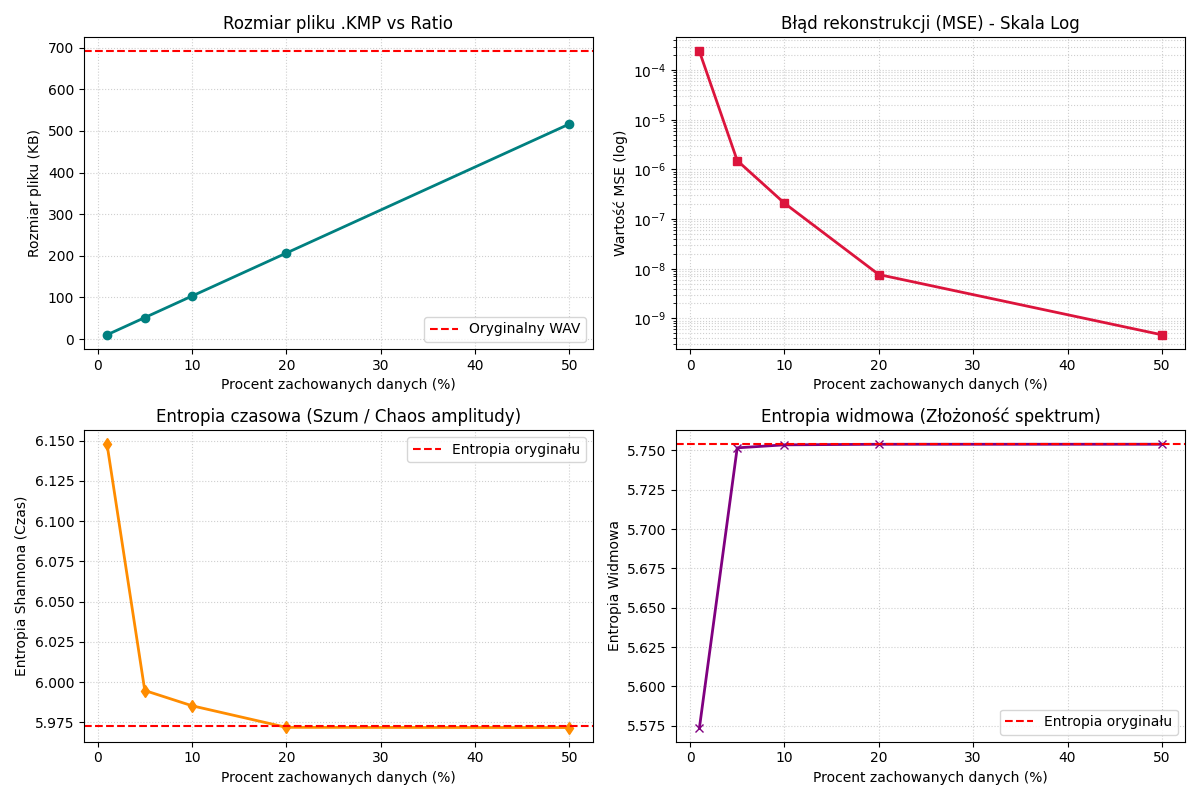


             PANEL ODSŁUCHU PORÓWNAWCZEGO

[REFERENCE] ORYGINALNY SYGNAŁ (WAV):

Sygnał oryginalny (.wav): Rozmiar: 690.88 KB


--------------------------------------------------

Sygnał skompresowany: 1.0% danych (Rozmiar: 10.36 KB | Redukcja: 98.50%)



Sygnał skompresowany: 5.0% danych (Rozmiar: 51.70 KB | Redukcja: 92.52%)



Sygnał skompresowany: 10.0% danych (Rozmiar: 103.38 KB | Redukcja: 85.04%)



Sygnał skompresowany: 20.0% danych (Rozmiar: 206.74 KB | Redukcja: 70.08%)



Sygnał skompresowany: 50.0% danych (Rozmiar: 516.82 KB | Redukcja: 25.19%)


In [29]:
import numpy as np
import os
import shutil
from IPython.display import Audio, display
import scipy.io.wavfile as wav
from scipy.stats import entropy 
from KmpKoder import koder_wav_do_kmp, dekoder_kmp_do_wav
import matplotlib.pyplot as plt

# --- 1. KONFIGURACJA ---
input_dir = 'data/source'
output_dir = 'data/compressed_2'

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# Ścieżka do pliku wejściowego WAV
source_name = 'gitara_strun_ma_wiele'
# source_name = 'surprise'
source_wav_path = f'{input_dir}/{source_name}.wav'


# Lista progów kompresji do sprawdzenia
ratios_to_test = [0.01, 0.05, 0.10, 0.20, 0.50]

results_size = []
results_mse = []
results_entropy = []
results_entropy_widmowa = []
audio_clips = {} # Słownik na odkodowane próbki do późniejszego odsłuchu

# Wczytujemy oryginał raz do obliczenia MSE i dla odsłuchu
rate_orig, data_orig = wav.read(source_wav_path)
if len(data_orig.shape) > 1:
    data_orig = data_orig.mean(axis=1)
data_orig_float = data_orig.astype(np.float32) / 32768.0

# Funkcja pomocnicza do liczenia entropii sygnału audio
def oblicz_entropie_sygnalu(signal_float, bins=1024):
    # Tworzymy histogram rozkładu amplitud
    hist, _ = np.histogram(signal_float, bins=bins, density=True)
    # Dodajemy małą wartość (1e-12), żeby uniknąć log(0) w obliczeniach
    hist = hist + 1e-12
    return entropy(hist)

def oblicz_entropie_widmowa(signal_float):
    # 1. Liczymy FFT z sygnału (w czasie)
    fft_vals = np.fft.rfft(signal_float)
    
    # 2. Liczymy gęstość mocy (Power Spectral Density)
    psd = np.abs(fft_vals) ** 2
    
    # 3. Normalizujemy do rozkładu prawdopodobieństwa (suma musi być = 1)
    psd_norm = psd / np.sum(psd)
    
    # 4. Liczymy entropię Shannona z unormowanego widma
    return entropy(psd_norm)

orig_entropy = oblicz_entropie_sygnalu(data_orig_float)
orig_entropy_widmowa = oblicz_entropie_widmowa(data_orig_float)
size_orig_wav = os.path.getsize(source_wav_path) / 1024

print("--- ROZPOCZĘCIE AUTOMATYCZNEJ ANALIZY ---")

for ratio in ratios_to_test:
    test_kmp_path = f'{output_dir}/compressed_ratio_{ratio}.kmp'
    test_wav_path = f'{output_dir}/compressed_ratio_{ratio}_decoded.wav'
    
    # Koder -> Dekoder
    koder_wav_do_kmp(source_wav_path, test_kmp_path, ratio)
    decoded_data, sample_rate = dekoder_kmp_do_wav(test_kmp_path, test_wav_path)
    
    # Zapisujemy tablicę audio do słownika, żeby odtworzyć ją na końcu
    audio_clips[ratio] = decoded_data
    
    # Skalujemy zdekodowany int16 do float dla MSE
    decoded_float = decoded_data.astype(np.float32) / 32767.0
    
# Obliczenia metryk
    kmp_size_kb = os.path.getsize(test_kmp_path) / 1024
    mse_val = np.mean((data_orig_float - decoded_float) ** 2)
    entropy_val = oblicz_entropie_sygnalu(decoded_float) # <--- OBLICZANIE ENTROPII
    entropy_widmowa_val = oblicz_entropie_widmowa(decoded_float) # <--- OBLICZANIE ENTROPII WIDMOWEJ

    results_size.append(kmp_size_kb)
    results_mse.append(mse_val)
    results_entropy.append(entropy_val)
    results_entropy_widmowa.append(entropy_widmowa_val)
    
    print(f"Ratio {ratio*100}% -> KMP: {kmp_size_kb:.2f} KB, MSE: {mse_val:.6f}, Entropia: {entropy_val:.4f}\n")

# --- 3. GENEROWANIE 4 WYKRESÓW W UKŁADZIE 2x2 ---
fig, axs = plt.subplots(2, 2, figsize=(12, 8))  # Układ 2 wiersze, 2 kolumny

# Wykres 1 (Wiersz 0, Kolumna 0): Rozmiar pliku
axs[0, 0].plot(np.array(ratios_to_test) * 100, results_size, 'o-', color='teal', linewidth=2)
axs[0, 0].axhline(y=size_orig_wav, color='r', linestyle='--', label='Oryginalny WAV')
axs[0, 0].set_title("Rozmiar pliku .KMP vs Ratio")
axs[0, 0].set_xlabel("Procent zachowanych danych (%)")
axs[0, 0].set_ylabel("Rozmiar pliku (KB)")
axs[0, 0].grid(True, linestyle=':', alpha=0.6)
axs[0, 0].legend()

# Wykres 2 (Wiersz 0, Kolumna 1): Błąd MSE
axs[0, 1].plot(np.array(ratios_to_test) * 100, results_mse, 's-', color='crimson', linewidth=2)
axs[0, 1].set_yscale('log')
axs[0, 1].set_title("Błąd rekonstrukcji (MSE) - Skala Log")
axs[0, 1].set_xlabel("Procent zachowanych danych (%)")
axs[0, 1].set_ylabel("Wartość MSE (log)")
axs[0, 1].grid(True, which="both", linestyle=':', alpha=0.6)

# Wykres 3 (Wiersz 1, Kolumna 0): Entropia Czasowa (Rozkład amplitud)
axs[1, 0].plot(np.array(ratios_to_test) * 100, results_entropy, 'd-', color='darkorange', linewidth=2)
axs[1, 0].axhline(y=orig_entropy, color='r', linestyle='--', label='Entropia oryginału')
axs[1, 0].set_title("Entropia czasowa (Szum / Chaos amplitudy)")
axs[1, 0].set_xlabel("Procent zachowanych danych (%)")
axs[1, 0].set_ylabel("Entropia Shannona (Czas)")
axs[1, 0].grid(True, linestyle=':', alpha=0.6)
axs[1, 0].legend()

# Wykres 4 (Wiersz 1, Kolumna 1): Entropia Widmowa (Zawartość informacji)
axs[1, 1].plot(np.array(ratios_to_test) * 100, results_entropy_widmowa, 'x-', color='purple', linewidth=2)
axs[1, 1].axhline(y=orig_entropy_widmowa, color='r', linestyle='--', label='Entropia oryginału')
axs[1, 1].set_title("Entropia widmowa (Złożoność spektrum)")
axs[1, 1].set_xlabel("Procent zachowanych danych (%)")
axs[1, 1].set_ylabel("Entropia Widmowa")
axs[1, 1].grid(True, linestyle=':', alpha=0.6)
axs[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{output_dir}/pelna_analiza_kompresji.png', dpi=300)
plt.show()

# --- SEKCO ODSŁUCHU PORÓWNAWCZEGO ---
print("\n" + "="*50)
print("             PANEL ODSŁUCHU PORÓWNAWCZEGO")
print("="*50)

print("\n[REFERENCE] ORYGINALNY SYGNAŁ (WAV):")
kmp_size = os.path.getsize(f'{input_dir}/{source_name}.wav') / 1024
print(f"\nSygnał oryginalny (.wav): Rozmiar: {kmp_size:.2f} KB")
display(Audio(data_orig, rate=rate_orig))
print("-" * 50)

# Pętla generująca odtwarzacze dla każdego ratio
for ratio in ratios_to_test:
    percentage = ratio * 100
    kmp_size = os.path.getsize(f'{output_dir}/compressed_ratio_{ratio}.kmp') / 1024
    reduction = 100 * (1 - kmp_size / size_orig_wav)
    
    print(f"\nSygnał skompresowany: {percentage}% danych (Rozmiar: {kmp_size:.2f} KB | Redukcja: {reduction:.2f}%)")
    display(Audio(audio_clips[ratio], rate=sample_rate))

### **6.3 Wnioski**

**Wyniki eksperymentu przeprowadzonego na 4 sekundowym nagraniu gitary:**
![image](.\data\source\pelna_analiza_kompresji.png)

Przeprowadzony eksperyment dowodzi wysokiej efektywności autorskiego formatu .kmp, który pozwolił na uzyskanie realnej, liniowej oszczędności pamięci masowej na dysku (redukcja rozmiaru z ok. $700\text{ KB}$ do ok. $100\text{ KB}$ przy zachowaniu $10\%$ danych) poprzez całkowite odrzucenie zerowych współczynników widmowych, co w klasycznym pliku WAV PCM było niemożliwe. Analiza błędu rekonstrukcji wykazała wykładniczy wzrost $MSE$ przy silniejszym wycinaniu pasma. Koreluje to bezpośrednio z badaniem entropii: gwałtowny wzrost entropii czasowej poniżej progu $10\%$ sygnalizuje pojawienie się chaosu i zniekształceń w przebiegu fali, podczas gdy stabilizacja entropii widmowej na poziomie oryginału już przy $5\%$ zachowanych składowych jednoznacznie potwierdza rzadkość widmową sygnału gitary i dowodzi, że pozostałe $95\%$ spektrum stanowiło jedynie nieistotne tło szumowe. W konsekwencji, próg kompresji dla badanego pliku na poziomie $10\%$ stanowi optymalny punkt pracy kodera, gwarantujący blisko siedmiokrotne odchudzenie pliku przy zachowaniu pełnej czytelności brzmienia i minimalnej, akceptowalnej dla ucha degradacji jakości audio.

---

## 7. Podsumowanie

Przeprowadzone badania jednoznacznie potwierdzają, że Dyskretna Transformata Fouriera jest to fundamentalne narzędzie, oferujące potężne możliwości w zakresie analizy i kompresji sygnałów. Kluczowym wnioskiem z etapu programistycznego jest fakt, że choć autorska implementacja oparta na bezpośrednim mnożeniu macierzy poprawnie odzwierciedla definicję matematyczną, to w praktyce inżynierskiej optymalizacja biblioteczna NumPy jest niezastąpiona pod kątem szybkości działania. W przypadku wykonywania testów dla kilku tysięcy sygnałów, algorytm niezoptymalizowany uniemożliwi wykonania eksperymentu w sensownym czasie.  

W kontekście syntezy danych wykazano, że baza Fouriera najefektywniej radzi sobie z sygnałami typu multisine, podczas gdy sygnały APRBS, ze względu na swoją skokową i nieregularną charakterystykę, bardzo słabo poddają się kompresji widmowej. Ewaluacja wierności rekonstrukcji dowodzi, że analiza zachowania energii sygnału niesie tak samo istotną informację diagnostyczną jak wskaźnik błędu średniokwadratowego ($MSE$). Optymalizacja metryka błędu maksymalnego ($Max\ Error$) okazała się mało wydajna i nie dawała satysfakcjonujących rezultatów.

Eksperymenty z kompresją dźwięku udowodniły, że w procesie redukcji rozmiaru plików audio nie ma konieczności rygorystycznego dążenia do idealnej dokładności na poziomie $99.9\%$. Świadome i kontrolowane zejście z wierności odtworzenia pozwala na drastyczne zredukowanie liczby pozostawionych współczynników widma, co przekłada się na gigantyczną oszczędność miejsca na dysku i czasu przesyłu pliku przy zachowaniu w pełni zadowalającej, trudnej do uchwycenia dla ludzkiego ucha jakości dźwięku.